<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/postpaid_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task: Consolidate Postpaid Data
The objective is to extract 13 specific Google Sheets from the `postpaid data` directory, harmonize their columns, and merge them into a single, clean, and normalized dataset ready for querying.

## 1. Authentication and Environment Setup

Authenticate the Google Colab environment to access Google Sheets and import required libraries.

In [15]:
import pandas as pd
import gspread
import glob
import os
import re
from google.colab import auth
from google.auth import default

# Authenticate the user
auth.authenticate_user()

# Get credentials and authorize gspread
creds, _ = default()
gc = gspread.authorize(creds)

print("Libraries imported and authentication successful.")

Libraries imported and authentication successful.


## 2. Mount Google Drive

Mount Google Drive to access the `.gsheet` files directly from your specific folder.

In [16]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## 3. Verify Target Directory

Locate the specific postpaid data files in the designated path.

In [17]:
# Define the specific target directory
target_dir = '/content/drive/MyDrive/2026/other/ed sa/postpaid data/'

# Find all .gsheet files in this directory
target_files = glob.glob(os.path.join(target_dir, '*.gsheet'))

print(f"Found {len(target_files)} .gsheet files in the target directory.")
if target_files:
    for f in sorted(target_files):
        print(os.path.basename(f))

Found 13 .gsheet files in the target directory.
postpaid april 2026.gsheet
postpaid august 2025.gsheet
postpaid december 2025.gsheet
postpaid february 2026.gsheet
postpaid january 2026.gsheet
postpaid july 2025.gsheet
postpaid june 2025.gsheet
postpaid june 2026.gsheet
postpaid march 2026.gsheet
postpaid may 2026.gsheet
postpaid november 2025.gsheet
postpaid october 2025.gsheet
postpaid september 2025.gsheet


## 4. Extract Data

Iterate over the verified files, extract the temporal feature (month and year) from the filename, and load the data via `gspread`.

In [18]:
dfs = []
date_pattern = r'([A-Za-z]+)\s+(\d{4})'

for filepath in target_files:
    filename = os.path.basename(filepath)
    try:
        # The file title in Drive is usually the filename without .gsheet
        sheet_title = filename.replace('.gsheet', '')

        # Extract temporal feature (Month Year) from filename
        match = re.search(date_pattern, filename, re.IGNORECASE)
        temporal_feature = f"{match.group(1).capitalize()} {match.group(2)}" if match else "Unknown"

        # Open the sheet via gspread using the title
        spreadsheet = gc.open(sheet_title)
        worksheet = spreadsheet.sheet1

        # Use get_all_values() to bypass header duplication errors
        data = worksheet.get_all_values()

        if data and len(data) > 1:
            headers = data[0]
            df = pd.DataFrame(data[1:], columns=headers)
            df['source_file'] = filename
            df['temporal_feature'] = temporal_feature
            dfs.append(df)
            print(f"Loaded: {filename}")

    except Exception as e:
        print(f"Failed to load {filename}: {e}")

print(f"\nTotal DataFrames successfully loaded: {len(dfs)}")

Loaded: postpaid august 2025.gsheet
Loaded: postpaid may 2026.gsheet
Loaded: postpaid april 2026.gsheet
Loaded: postpaid march 2026.gsheet
Loaded: postpaid november 2025.gsheet
Loaded: postpaid september 2025.gsheet
Loaded: postpaid february 2026.gsheet
Loaded: postpaid january 2026.gsheet
Loaded: postpaid july 2025.gsheet
Loaded: postpaid june 2026.gsheet
Loaded: postpaid december 2025.gsheet
Loaded: postpaid june 2025.gsheet
Loaded: postpaid october 2025.gsheet

Total DataFrames successfully loaded: 13


## 5. Harmonize and Combine

Deduplicate column names for each DataFrame to avoid `InvalidIndexError`, concatenate them into a single `combined_df`, and standardize column names.

In [19]:
def make_unique(cols):
    seen = {}
    result = []
    for c in cols:
        c = str(c)
        if c in seen:
            seen[c] += 1
            result.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            result.append(c)
    return result

combined_df = pd.DataFrame()

if dfs:
    for df in dfs:
        df.columns = make_unique(df.columns)

    combined_df = pd.concat(dfs, ignore_index=True)

    # Standardize column names
    combined_df.columns = combined_df.columns.str.lower().str.strip().str.replace(' ', '_')
    print(f"Combined DataFrame constructed successfully.")
else:
    print("No DataFrames were loaded to merge.")

Combined DataFrame constructed successfully.


## 6. Final Results

Display the final dataset shape, info, and a preview.

In [20]:
if not combined_df.empty:
    print(f"Final dataset shape: {combined_df.shape}")
    combined_df.info()
    display(combined_df.head())
else:
    print("Dataset is empty.")

Final dataset shape: (36050, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36050 entries, 0 to 36049
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   no                         24564 non-null  object
 1   region                     33934 non-null  object
 2                              31093 non-null  object
 3   district                   33934 non-null  object
 4   billing_period             33934 non-null  object
 5   from_date                  33934 non-null  object
 6   _1                         31093 non-null  object
 7   to_date                    33934 non-null  object
 8   document#                  33934 non-null  object
 9   customer                   33934 non-null  object
 10  _2                         31093 non-null  object
 11  _3                         31093 non-null  object
 12  account#                   33934 non-null  object
 13  invoice#                   3

,no,region,,district,billing_period,from_date,_1,to_date,document#,customer,...,anomalies,supply_address,_8,pole_number,source_file,temporal_feature,no,govt_acct__in_ouc,govt._acct.,govt._acct._in_ouc
0,1,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,...,Y,"51 HANGA ROAD,9382,-,41-KENEMA",,1000000025,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
1,2,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$44107877,THE MANAGER BSL,...,N,"2 DAMA ROAD,9383,-,41-KENEMA",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
2,3,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,...,N,"TISSOR VILLAGE,9385,-,41-KENEMA",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
3,4,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",...,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
4,5,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,...,N,"41, 12 DAMA RD",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN


### 6.1 Data Cleaning: Drop Empty and Unnamed Columns
Remove columns that are artifacts of empty headers (e.g., `_1`, `_2`) or contain entirely empty/null values.

In [27]:
import re
import numpy as np

# 1. Identify and drop columns that are empty strings or match the pattern _1, _2, etc.
unnamed_cols = [col for col in combined_df.columns if str(col).strip() == '' or re.match(r'^_\d+$', str(col))]
print(f"Dropping unnamed/spacer columns: {unnamed_cols}")
combined_df.drop(columns=unnamed_cols, inplace=True)

# 2. Replace empty strings/whitespace with NaN to properly detect entirely empty columns
combined_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# 3. Drop columns where ALL values are NaN
combined_df.dropna(axis=1, how='all', inplace=True)

print(f"\nDataset shape after removing empty columns: {combined_df.shape}")
combined_df.info()
display(combined_df.head())

Dropping unnamed/spacer columns: ['', '_1', '_2', '_3', '_4', '_5', '_6', '_7', '_8']


/tmp/ipykernel_685/1219184186.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)



Dataset shape after removing empty columns: (36050, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36050 entries, 0 to 36049
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   no                         24560 non-null  object
 1   region                     33930 non-null  object
 2   district                   33930 non-null  object
 3   billing_period             33930 non-null  object
 4   from_date                  33930 non-null  object
 5   to_date                    33930 non-null  object
 6   document#                  33930 non-null  object
 7   customer                   33930 non-null  object
 8   account#                   33930 non-null  object
 9   invoice#                   33605 non-null  object
 10  bill_#                     33930 non-null  object
 11  generation_date            33930 non-null  object
 12  issue_date                 33930 non-null  object
 13  due_

,no,region,district,billing_period,from_date,to_date,document#,customer,account#,invoice#,...,billed_consumption,anomalies,supply_address,pole_number,source_file,temporal_feature,no,govt_acct__in_ouc,govt._acct.,govt._acct._in_ouc
0,1,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,1000037610,202508EIN0004392114,...,0,Y,"51 HANGA ROAD,9382,-,41-KENEMA",1000000025,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
1,2,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,UTIL$44107877,THE MANAGER BSL,1000037628,202508EIN0004464573,...,4 943.20,N,"2 DAMA ROAD,9383,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
2,3,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,1000037644,202508EIN0004464572,...,18 061.60,N,"TISSOR VILLAGE,9385,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
3,4,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",1000396762,202508EIN0004238650,...,1 621.08,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
4,5,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,1002541019,202508EIN0004486376,...,2 444.58,N,"41, 12 DAMA RD",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN


## 7. Export to CSV
Export the harmonized dataset to a CSV file for future use.

In [28]:
import os

# Define the output path in the same Google Drive directory
output_filename = 'cleaned_combined_postpaid_data.csv'
output_path = os.path.join(target_dir, output_filename)

# Export the cleaned DataFrame to CSV
combined_df.to_csv(output_path, index=False)
print(f"Cleaned data successfully exported to: {output_path}")

Cleaned data successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/cleaned_combined_postpaid_data.csv


In [21]:
# Cleaned up

In [22]:
# Cleaned up

In [23]:
# Cleaned up

In [24]:
# Cleaned up

In [25]:
# Cleaned up

## 8. Summary Statistics
Let's generate the summary statistics for the final cleaned DataFrame.

In [29]:
# Generate summary statistics for all columns
display(combined_df.describe(include='all'))

,no,region,district,billing_period,from_date,to_date,document#,customer,account#,invoice#,...,billed_consumption,anomalies,supply_address,pole_number,source_file,temporal_feature,no,govt_acct__in_ouc,govt._acct.,govt._acct._in_ouc
count,24560,33930,33930,33930,33930,33930,33930,33930,33930,33605,...,35896,36046,36046,33919,36050,36050,9370,2841,1966,3933
unique,3390,5,21,13,13,13,3532,3253,3573,33605,...,9130,2,3506,23,13,13,3933,256,230,275
top,1771,WESTERN,82-FREETOWN EAST RURAL,5-May 2026,2026-05-01,2026-05-31,SLDL00493,"KAMARA, MOHAMED",500674748,202510EIN0005741633,...,0,N,"78, 5 GLOUSTER STREET",1000000012,postpaid june 2026.gsheet,June 2026,2596,#N/A,#N/A,#N/A
freq,9,32118,14946,3482,3482,3482,53,118,1029,1,...,17330,23824,52,7620,3933,3933,3,2586,1737,3647


## 9. Data Visualization
Let's visualize the distribution of our records by region using a bar chart.

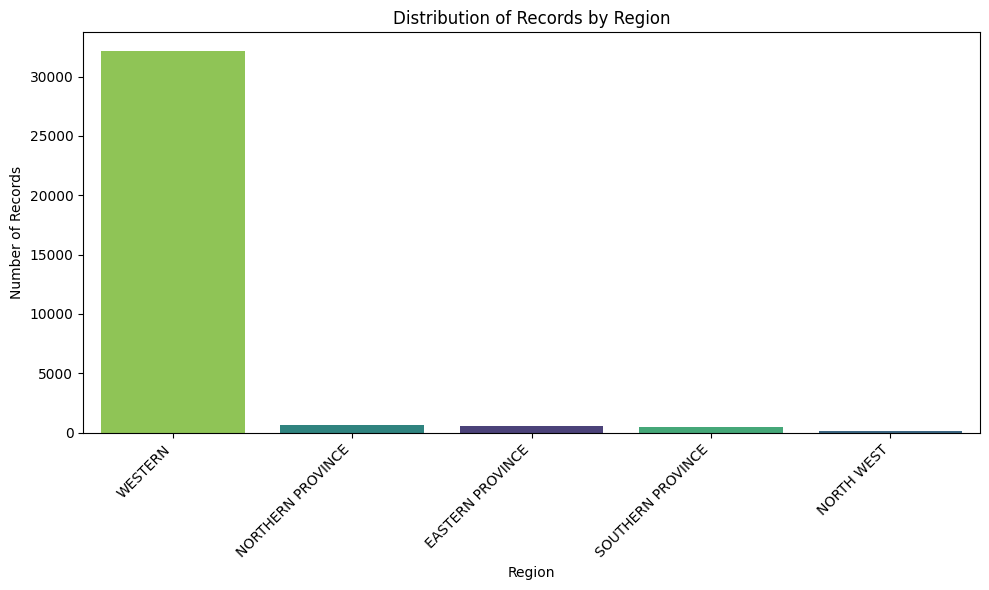

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Create a count plot for the 'region' column
sns.countplot(data=combined_df, x='region',
              hue='region',
              order=combined_df['region'].value_counts().index,
              palette='viridis',
              legend=False)

# Add titles and labels
plt.title('Distribution of Records by Region')
plt.xlabel('Region')
plt.ylabel('Number of Records')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## 10. Document Number Assessment
Let's analyze the `document#` field to check for unique values, duplicates, missing values, and general formatting.

In [32]:
# 1. Basic Summary Statistics
print("--- Basic Summary ---")
display(combined_df['document#'].describe())

# 2. Missing Values
missing_docs = combined_df['document#'].isnull().sum()
print(f"\nMissing/Null Document Numbers: {missing_docs}")

# 3. Top 10 Most Frequent Document Numbers
print("\n--- Top 10 Most Frequent Document Numbers ---")
display(combined_df['document#'].value_counts().head(10))

# 4. Analyze String Lengths (to check for consistent formatting)
print("\n--- Document Number Length Distribution ---")
# Convert to string, ignoring NaNs for length calculation
doc_lengths = combined_df['document#'].dropna().astype(str).str.len()
display(doc_lengths.value_counts().sort_index())

# 5. Check for common prefixes or patterns
print("\n--- Top 5 Common Prefixes (First 4 Characters) ---")
prefixes = combined_df['document#'].dropna().astype(str).str[:4]
display(prefixes.value_counts().head(5))

--- Basic Summary ---


,document#
count,33930
unique,3532
top,SLDL00493
freq,53



Missing/Null Document Numbers: 2120

--- Top 10 Most Frequent Document Numbers ---


,count
document#,
SLDL00493,53
SLDL00509,39
2540736,35
74349278,29
SLDL00486,25
SLDL00833,24
SLDL00528,24
PREP$4-78 -4452,24
SLDL00755,24



--- Document Number Length Distribution ---


,count
document#,
3,32
4,145
5,768
6,141
7,6545
8,3630
9,9389
10,216
11,469



--- Top 5 Common Prefixes (First 4 Characters) ---


,count
document#,
SLDL,9459
UTIL,7209
PREP,4800
1821,1382
AMI$,937


## 11. Customer and Account Number Assessment
Continuing our field-by-field EDA, let's explore the `customer` and `account#` fields to understand user distribution and account formatting.

In [33]:
# --- 1. Customer Field Assessment ---
print("========== CUSTOMER FIELD ==========")
print("--- Basic Summary ---")
display(combined_df['customer'].describe())

missing_customers = combined_df['customer'].isnull().sum()
print(f"\nMissing/Null Customers: {missing_customers}")

print("\n--- Top 10 Most Frequent Customers ---")
display(combined_df['customer'].value_counts().head(10))

print("\n\n========== ACCOUNT# FIELD ==========")
# --- 2. Account# Field Assessment ---
print("--- Basic Summary ---")
display(combined_df['account#'].describe())

missing_accounts = combined_df['account#'].isnull().sum()
print(f"\nMissing/Null Account Numbers: {missing_accounts}")

print("\n--- Top 10 Most Frequent Account Numbers ---")
display(combined_df['account#'].value_counts().head(10))

print("\n--- Account Number Length Distribution ---")
# Convert to string, ignoring NaNs for length calculation
acct_lengths = combined_df['account#'].dropna().astype(str).str.len()
display(acct_lengths.value_counts().sort_index())

========== CUSTOMER FIELD ==========
--- Basic Summary ---


,customer
count,33930
unique,3253
top,"KAMARA, MOHAMED"
freq,118



Missing/Null Customers: 2120

--- Top 10 Most Frequent Customers ---


,count
customer,
"KAMARA, MOHAMED",118
"JALLOH, MOHAMED",94
"SESAY, IBRAHIM",91
"BANGURA, MOHAMED",82
"KAMARA, IBRAHIM",69
MINISTRY OF HEALTH,65
"KAMARA, FODAY",58
SIERRATEL,53
"SESAY, OSMAN",53




========== ACCOUNT# FIELD ==========
--- Basic Summary ---


,account#
count,33930
unique,3573
top,500674748
freq,1029



Missing/Null Account Numbers: 2120

--- Top 10 Most Frequent Account Numbers ---


,count
account#,
500674748,1029
1000044784,14
1000041145,14
500259866,14
500165931,13
1002916748,12
1002984924,12
500113782,12
500113808,12



--- Account Number Length Distribution ---


,count
account#,
9,21264
10,12666


## 12. Billing Period and Status Assessment
Let's analyze the `billing_period`, `billing_status`, and `collection_status` fields to see how the billing cycles are distributed and check the payment/collection states.

In [34]:
print("========== BILLING PERIOD ==========")
# Check the distribution of billing periods
display(combined_df['billing_period'].value_counts())
print(f"\nMissing/Null Billing Periods: {combined_df['billing_period'].isnull().sum()}")

print("\n\n========== BILLING STATUS ==========")
# Check billing status distribution
display(combined_df['billing_status'].value_counts(dropna=False))

print("\n\n========== COLLECTION STATUS ==========")
# Check collection status distribution
display(combined_df['collection_status'].value_counts(dropna=False))

========== BILLING PERIOD ==========


,count
billing_period,
5-May 2026,3482
10-October 2025,3391
6-June 2026,3285
7-July 2025,3199
6-June 2025,3184
8-August 2025,2915
12-December 2025,2778
1-January 2026,2756
2-February 2026,2604



Missing/Null Billing Periods: 2120


========== BILLING STATUS ==========


,count
billing_status,
Invoiced,35618
Generated,325
Invoicing,92
Rebilled,11
NaN,4




========== COLLECTION STATUS ==========


,count
collection_status,
Invoiced,34841
Paid,788
NaN,421


## 13. Financials and Consumption Assessment
Let's convert `total_amount`, `pending_amount`, and `billed_consumption` into numerical data types and analyze their distributions.

In [35]:
# Define the target columns
numeric_cols = ['total_amount', 'pending_amount', 'billed_consumption']

# Clean and convert to numeric
for col in numeric_cols:
    # Remove commas and spaces, then convert to numeric (setting invalid parsing to NaN)
    combined_df[col] = combined_df[col].astype(str).str.replace(',', '', regex=False).str.strip()
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

print("========== FINANCIALS & CONSUMPTION SUMMARY ==========")
display(combined_df[numeric_cols].describe())

print("\n========== MISSING VALUES ==========")
display(combined_df[numeric_cols].isnull().sum())

========== FINANCIALS & CONSUMPTION SUMMARY ==========


,total_amount,pending_amount,billed_consumption
count,27134.000000,27653.000000,28978.000000
mean,129.770338,126.255672,52.803132
std,190.811801,188.996342,142.147534
min,-981.600000,0.000000,0.000000
25%,13.000000,13.000000,0.000000
50%,13.000000,13.000000,0.000000
75%,202.270000,193.580000,43.000000
max,999.410000,999.410000,999.720000



========== MISSING VALUES ==========


,0
total_amount,8916
pending_amount,8397
billed_consumption,7072


## 14. Date Fields Assessment
Let's analyze the temporal fields: `from_date`, `to_date`, `generation_date`, `issue_date`, and `due_date`. We will convert them to datetime objects to properly assess their ranges.

In [36]:
date_cols = ['from_date', 'to_date', 'generation_date', 'issue_date', 'due_date']

print("========== DATE FIELDS SUMMARY ==========")
for col in date_cols:
    # Convert to datetime, coercing errors to NaT (Not a Time)
    combined_df[col] = pd.to_datetime(combined_df[col], errors='coerce')

    print(f"\n--- {col.upper()} ---")
    print(f"Missing Values: {combined_df[col].isnull().sum()}")
    if not combined_df[col].dropna().empty:
        print(f"Min Date: {combined_df[col].min().date()}")
        print(f"Max Date: {combined_df[col].max().date()}")

========== DATE FIELDS SUMMARY ==========

--- FROM_DATE ---
Missing Values: 2120
Min Date: 2025-06-01
Max Date: 2026-06-01

--- TO_DATE ---
Missing Values: 2120
Min Date: 2025-06-30
Max Date: 2026-06-30

--- GENERATION_DATE ---
Missing Values: 2120
Min Date: 2025-06-09
Max Date: 2026-06-30

--- ISSUE_DATE ---
Missing Values: 2120
Min Date: 2025-06-09
Max Date: 2026-06-30

--- DUE_DATE ---
Missing Values: 2445
Min Date: 2025-06-16
Max Date: 2026-07-14


## 15. Categorical and Service Fields Assessment
Let's examine the distributions of `service`, `contracted_service_status`, `billing_type`, `bill_type`, `tariff`, `vat`, and `anomalies`.

In [37]:
cat_cols = ['service', 'contracted_service_status', 'billing_type', 'bill_type', 'tariff', 'vat', 'anomalies']

print("========== CATEGORICAL FIELDS SUMMARY ==========")
for col in cat_cols:
    print(f"\n--- {col.upper()} ---")
    # Display top 10 most frequent values including NaNs
    display(combined_df[col].value_counts(dropna=False).head(10))

========== CATEGORICAL FIELDS SUMMARY ==========

--- SERVICE ---


,count
service,
Electricity Postpaid,33930
NaN,2120



--- CONTRACTED_SERVICE_STATUS ---


,count
contracted_service_status,
Active,33672
NaN,2131
Pending termination,241
Terminated,6



--- BILLING_TYPE ---


...

,count
tariff,
T1-Residential - Postpayment,25397
T4-MDI – Postpayment-Monthly,9068
T2-Commercial – Postpayment,788
T3-Institutions – Postpayment,419
T4-MDI-Postpayment-Biweekly,293
T1-Residential - Prepayment,40
NaN,18
T7-Welders – Postpayment,11
T5-Street Lighting – Postpayment,9



--- VAT ---


,count
vat,
0,17575
20.89,283
21.52,238
22.15,190
18.99,181
27.85,176
15.19,166
20.26,164
19.62,156



--- ANOMALIES ---


,count
anomalies,
N,23824
Y,12222
NaN,4


## 16. Remaining Text and Geographical Fields
Let's wrap up our field assessment by looking at `tariff`, `anomalies`, `supply_address`, and `pole_number`.

In [38]:
remaining_cols = ['tariff', 'anomalies', 'supply_address', 'pole_number']

print("========== REMAINING FIELDS SUMMARY ==========")
for col in remaining_cols:
    if col in combined_df.columns:
        print(f"\n--- {col.upper()} ---")
        print(f"Missing Values: {combined_df[col].isnull().sum()}")
        display(combined_df[col].value_counts(dropna=False).head(10))
    else:
        print(f"\n--- {col.upper()} --- (Column not found in dataset)")

========== REMAINING FIELDS SUMMARY ==========

--- TARIFF ---
Missing Values: 18


,count
tariff,
T1-Residential - Postpayment,25397
T4-MDI – Postpayment-Monthly,9068
T2-Commercial – Postpayment,788
T3-Institutions – Postpayment,419
T4-MDI-Postpayment-Biweekly,293
T1-Residential - Prepayment,40
NaN,18
T7-Welders – Postpayment,11
T5-Street Lighting – Postpayment,9



--- ANOMALIES ---
Missing Values: 4


,count
anomalies,
N,23824
Y,12222
NaN,4



--- SUPPLY_ADDRESS ---
Missing Values: 4


,count
supply_address,
"78, 5 GLOUSTER STREET",52
"84, TOWER HILL",52
"84, LEICESTER PEAK",44
"81, 198 WILKINSON ROAD",39
"78, 14 WILBERFORCE STREET",39
"78, LOTTO HOUSE OAU DRIVE",39
"80, JOMOKENYATTA ROAD",32
"81, WILKINSON ROAD",26
"FL1,D,14,BRIMA LANE,82-FREETOWN EAST",26



--- POLE_NUMBER ---
Missing Values: 2131


,count
pole_number,
1000000012,7620
1000000013,6507
1000000025,5841
1000000014,4815
1000000016,2161
NaN,2131
1000000019,1750
1000000020,1500
1000000021,654


## 17. Bronze Dataset Creation
We will perform safe structural cleaning without altering the core business values. This includes stripping whitespace, standardizing missing values, and dropping completely empty or duplicated rows.

In [41]:
import numpy as np

print("========== BRONZE DATASET CLEANING ==========")
initial_rows = len(combined_df)

# Deduplicate columns just in case previous lowercasing created duplicates (e.g., 'No' and 'NO' -> 'no')
def make_unique_again(cols):
    seen = {}
    result = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            result.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            result.append(c)
    return result

combined_df.columns = make_unique_again(combined_df.columns)

# 1. Strip whitespace and standardize string 'nan'/empty strings to actual NaN
print("Stripping whitespace and standardizing nulls...")
for col in combined_df.select_dtypes(include=['object']).columns:
    # Only apply string methods to actual strings, avoiding altering non-string data inadvertently
    combined_df[col] = combined_df[col].astype(str).str.strip()
    combined_df[col] = combined_df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})

# 2. Drop rows where ALL core business fields are missing (ignoring our added metadata)
core_cols = [col for col in combined_df.columns if col not in ['source_file', 'temporal_feature']]
combined_df.dropna(subset=core_cols, how='all', inplace=True)
empty_rows_dropped = initial_rows - len(combined_df)
print(f"Dropped {empty_rows_dropped} completely empty business rows.")

# 3. Drop exact duplicate rows
current_rows = len(combined_df)
combined_df.drop_duplicates(inplace=True)
dupes_dropped = current_rows - len(combined_df)
print(f"Dropped {dupes_dropped} exact duplicate rows.")

print("\n--- Bronze Dataset Status ---")
print(f"Final Bronze Shape: {combined_df.shape}")
combined_df.info()

========== BRONZE DATASET CLEANING ==========
Stripping whitespace and standardizing nulls...
Dropped 2 completely empty business rows.
Dropped 11 exact duplicate rows.

--- Bronze Dataset Status ---
Final Bronze Shape: (36037, 35)
<class 'pandas.core.frame.DataFrame'>
Index: 36037 entries, 0 to 36049
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   no                         24560 non-null  object        
 1   region                     33930 non-null  object        
 2   district                   33930 non-null  object        
 3   billing_period             33930 non-null  object        
 4   from_date                  33930 non-null  datetime64[ns]
 5   to_date                    33930 non-null  datetime64[ns]
 6   document#                  33930 non-null  object        
 7   customer                   33930 non-null  object        
 8   account#                   33

In [40]:
# Export the formalized Bronze Dataset
bronze_output_filename = 'bronze_postpaid_data.csv'
bronze_output_path = os.path.join(target_dir, bronze_output_filename)

combined_df.to_csv(bronze_output_path, index=False)
print(f"Bronze dataset successfully exported to: {bronze_output_path}")

Bronze dataset successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/bronze_postpaid_data.csv


## 18. Pipeline Transformation Summary
Let's visualize how our dataset transformed from the initial raw merge to our finalized Bronze state.

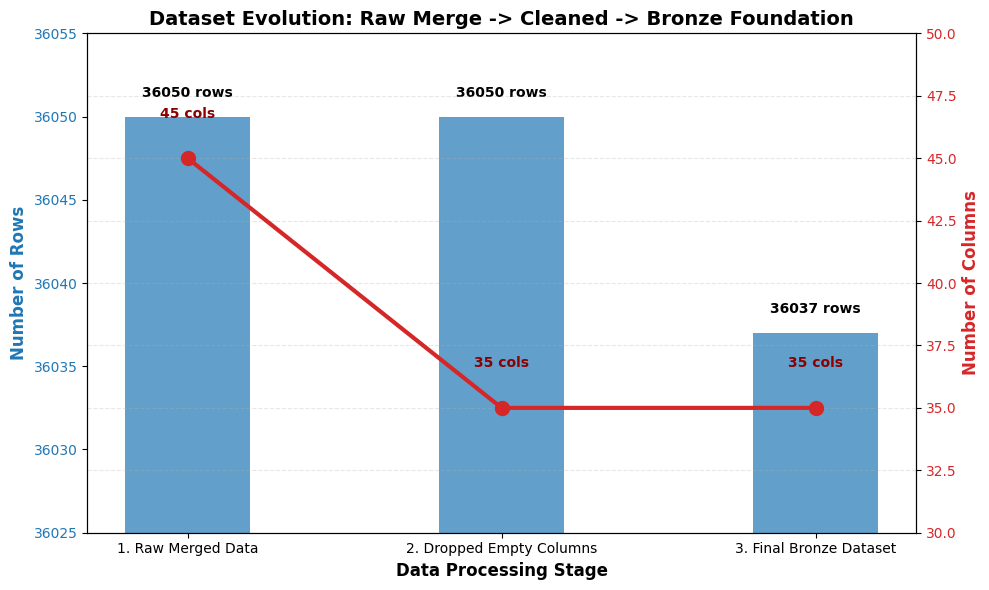

In [42]:
import matplotlib.pyplot as plt

# Data points representing the evolution of our dataset
stages = ['1. Raw Merged Data', '2. Dropped Empty Columns', '3. Final Bronze Dataset']
rows = [36050, 36050, 36037]
cols = [45, 35, 35]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for rows (Secondary Y-axis to zoom in on the small change)
color = 'tab:blue'
ax1.set_xlabel('Data Processing Stage', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Rows', color=color, fontweight='bold', fontsize=12)
bars = ax1.bar(stages, rows, color=color, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)
# Zoom the Y-axis heavily to show the drop of 13 rows
ax1.set_ylim(36025, 36055)

# Line chart for columns (Primary Y-axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Number of Columns', color=color, fontweight='bold', fontsize=12)
line = ax2.plot(stages, cols, color=color, marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(30, 50)

# Add text annotations for rows
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval} rows', ha='center', va='bottom', color='black', fontweight='bold')

# Add text annotations for columns
for i, txt in enumerate(cols):
    ax2.text(i, txt + 1.5, f'{txt} cols', ha='center', va='bottom', color='darkred', fontweight='bold')

plt.title('Dataset Evolution: Raw Merge -> Cleaned -> Bronze Foundation', fontweight='bold', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

## 19. Silver Dataset: Date Standardization & Dropping Sparse Columns
Let's fix the inconsistent date formats (specifically cleaning `billing_period`) and remove the highly sparse `govt` columns that are cluttering the dataset.

In [43]:
# 1. Standardize 'billing_period'
print("--- Standardizing Dates ---")
# Remove prefixes like '8-' from '8-August 2025'
combined_df['billing_period'] = combined_df['billing_period'].astype(str).str.replace(r'^\d+-', '', regex=True)

# Convert to a standard YYYY-MM format
combined_df['billing_period'] = pd.to_datetime(combined_df['billing_period'], errors='coerce').dt.strftime('%Y-%m')

# Standardize all other date columns to YYYY-MM-DD format
date_cols = ['from_date', 'to_date', 'generation_date', 'issue_date', 'due_date']
for col in date_cols:
    combined_df[col] = pd.to_datetime(combined_df[col], errors='coerce').dt.strftime('%Y-%m-%d')

display(combined_df[['billing_period'] + date_cols].head())


--- Standardizing Dates ---


/tmp/ipykernel_685/2921532586.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df['billing_period'] = pd.to_datetime(combined_df['billing_period'], errors='coerce').dt.strftime('%Y-%m')


,billing_period,from_date,to_date,generation_date,issue_date,due_date
0,2025-08,2025-08-01,2025-08-31,2025-08-26,2025-08-26,2025-08-29
1,2025-08,2025-08-01,2025-08-31,2025-08-16,2025-08-30,2025-09-02
2,2025-08,2025-08-01,2025-08-31,2025-08-15,2025-08-30,2025-09-02
3,2025-08,2025-08-01,2025-08-31,2025-08-18,2025-08-18,2025-09-01
4,2025-08,2025-08-01,2025-08-31,2025-08-15,2025-08-31,2025-09-15


In [44]:
# 2. Handle 'govt' columns
print("\n--- Assessing 'govt' columns ---")
govt_cols = [col for col in combined_df.columns if 'govt' in col.lower()]
print(f"Found 'govt' columns: {govt_cols}")

# Check how much data is actually missing in these columns
for col in govt_cols:
    missing_pct = combined_df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing")

# Drop them since they are almost entirely empty and not part of the core schema
print("\nDropping 'govt' columns to harmonize the dataset...")
combined_df.drop(columns=govt_cols, inplace=True)

print(f"Dataset shape is now: {combined_df.shape}")
display(combined_df.head())



--- Assessing 'govt' columns ---
Found 'govt' columns: ['govt_acct__in_ouc', 'govt._acct.', 'govt._acct._in_ouc']
govt_acct__in_ouc: 92.12% missing
govt._acct.: 94.54% missing
govt._acct._in_ouc: 89.09% missing

Dropping 'govt' columns to harmonize the dataset...
Dataset shape is now: (36037, 32)


,no,region,district,billing_period,from_date,to_date,document#,customer,account#,invoice#,...,itinerary,total_amount,pending_amount,billed_consumption,anomalies,supply_address,pole_number,source_file,temporal_feature,no_1
0,1,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,1000037610,202508EIN0004392114,...,3301 KENEMA-00001,310.4,310.4,0.0,Y,"51 HANGA ROAD,9382,-,41-KENEMA",1000000025,postpaid august 2025.gsheet,August 2025,NaN
1,2,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,UTIL$44107877,THE MANAGER BSL,1000037628,202508EIN0004464573,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,N,"2 DAMA ROAD,9383,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN
2,3,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,1000037644,202508EIN0004464572,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,N,"TISSOR VILLAGE,9385,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN
3,4,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",1000396762,202508EIN0004238650,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN
4,5,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,1002541019,202508EIN0004486376,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,N,"41, 12 DAMA RD",1000000002,postpaid august 2025.gsheet,August 2025,NaN


## 20. Deep Dive: Financial & Categorical Anomalies
Let's investigate potential data quality issues in our numeric fields (zeros, negatives, missing values) and check for text inconsistencies in our categorical fields.

In [45]:
print("--- 1. Financial & Consumption Deep Dive ---")
numeric_cols = ['total_amount', 'pending_amount', 'billed_consumption']

for col in numeric_cols:
    missing = combined_df[col].isna().sum()
    zeros = (combined_df[col] == 0).sum()
    negatives = (combined_df[col] < 0).sum()

    print(f"\n[{col.upper()}]")
    print(f"  - Missing (NaN): {missing} ({(missing/len(combined_df))*100:.1f}%)")
    print(f"  - Exactly Zero:  {zeros} ({(zeros/len(combined_df))*100:.1f}%)")
    print(f"  - Negative (<0): {negatives} ({(negatives/len(combined_df))*100:.1f}%)")

# Let's peek at some negative amounts if they exist
if (combined_df['total_amount'] < 0).any():
    print("\nSample of Negative Total Amounts:")
    display(combined_df[combined_df['total_amount'] < 0][['document#', 'total_amount', 'pending_amount', 'billing_status']].head())


--- 1. Financial & Consumption Deep Dive ---

[TOTAL_AMOUNT]
  - Missing (NaN): 8914 (24.7%)
  - Exactly Zero:  0 (0.0%)
  - Negative (<0): 2 (0.0%)

[PENDING_AMOUNT]
  - Missing (NaN): 8395 (23.3%)
  - Exactly Zero:  789 (2.2%)
  - Negative (<0): 0 (0.0%)

[BILLED_CONSUMPTION]
  - Missing (NaN): 7070 (19.6%)
  - Exactly Zero:  17319 (48.1%)
  - Negative (<0): 0 (0.0%)

Sample of Negative Total Amounts:


,document#,total_amount,pending_amount,billing_status
2979,PREP$1-41-075754,-981.6,0.0,Invoiced
2981,PREP$1-41-10897,-981.6,0.0,Invoiced


In [46]:
print("\n--- 2. Categorical Consistency Deep Dive ---")
cat_check_cols = ['region', 'district', 'contracted_service_status', 'billing_status']

for col in cat_check_cols:
    print(f"\n[{col.upper()}] Unique Values:")
    # Dropna to focus on the actual strings, then get value counts
    val_counts = combined_df[col].dropna().value_counts()
    print(val_counts.to_string())

    # Flag if there are suspicious lower/uppercase overlaps
    unique_lower = set(val.lower() for val in val_counts.index.astype(str))
    if len(unique_lower) < len(val_counts):
        print(f"  ⚠️ WARNING: Possible casing inconsistency detected in {col}!")



--- 2. Categorical Consistency Deep Dive ---

[REGION] Unique Values:
region
WESTERN              32118
NORTHERN PROVINCE      649
EASTERN PROVINCE       527
SOUTHERN PROVINCE      471
NORTH WEST             165

[DISTRICT] Unique Values:
district
82-FREETOWN EAST RURAL    14946
83-FREETOWN EAST           7029
80-FREETOWN WEST           2143
84-FREETOWN WEST RURAL     2124
81-FREETOWN WEST           1158
78-FREETOWN CENTRAL        1008
77-FREETOWN CENTRAL         683
70-FREETOWN CENTRAL         650
75-FREETOWN CENTRAL         602
79-FREETOWN CENTRAL         569
51-BOMBALI                  505
72-FREETOWN CENTRAL         497
31-BO                       471
41-KENEMA                   414
76-FREETOWN CENTRAL         225
74-FREETOWN CENTRAL         176
50-PORT LOKO                165
71-FREETOWN CENTRAL         155
73-FREETOWN CENTRAL         153
54-TONKOLILI                144
48-KONO                     113

[CONTRACTED_SERVICE_STATUS] Unique Values:
contracted_service_status
Active   

## 21. Silver Dataset Export
We have completed our "Silver" transformations (date standardization, dropping sparse columns, text formatting check, and retaining financial `NaN`s for data integrity). Let's export this analytical-ready dataset.

In [47]:
# Export the finalized Silver Dataset
silver_output_filename = 'silver_postpaid_data.csv'
silver_output_path = os.path.join(target_dir, silver_output_filename)

combined_df.to_csv(silver_output_path, index=False)
print(f"Silver dataset successfully exported to: {silver_output_path}")

# Final shape check
print(f"Final Silver Shape: {combined_df.shape}")

Silver dataset successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/silver_postpaid_data.csv
Final Silver Shape: (36037, 32)


## 22. Revised EDA Report & Methodology

### The Logic Behind Our EDA Process
Our Exploratory Data Analysis (EDA) and data engineering process followed a structured Medallion Architecture (Raw -> Bronze -> Silver) to ensure data integrity:

1. **Ingestion & Consolidation (Raw):**
   - We dynamically loaded 13 disjointed Google Sheets.
   - **Logic:** Harmonizing column headers was necessary because the sheets had duplicate/unnamed columns that would break standard pandas joins.
2. **Structural Cleaning (Bronze):**
   - Dropped purely empty rows and exact duplicates.
   - Stripped whitespace and standardized `NaN` values across text fields.
   - **Logic:** Before analyzing data, we must remove structural artifacts (like spacer columns `_1`, `_2`) to get an accurate row/column count of true business data.
3. **Semantic Cleaning & Formatting (Silver):**
   - Standardized `billing_period` to `YYYY-MM` and converted dates to `YYYY-MM-DD`.
   - Dropped highly sparse columns (e.g., `govt_acct__in_ouc` which were ~90%+ empty).
   - **Logic (Handling Financials):** We intentionally kept `NaN` values in `total_amount`, `pending_amount`, and `billed_consumption`. Filling these with `0` or `mean` averages would distort actual revenue calculations and mask underlying system issues (e.g., missing generation data).
4. **Deep Dive Profiling:**
   - Checked categorical fields for casing overlaps (e.g., making sure 'WESTERN' isn't split with 'Western').
   - Assessed numerical boundaries (identifying negative billings and exact zeros).

Below are the revised visualizations based on our cleaned **Silver Dataset**.

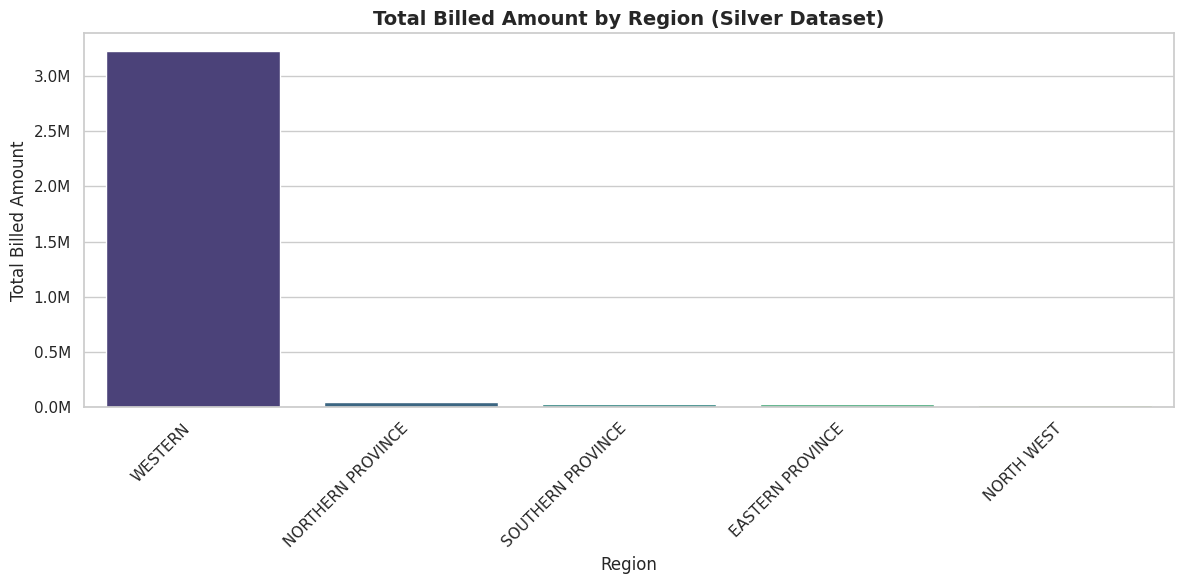

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set general style
sns.set_theme(style="whitegrid")

# 1. Financial Overview: Total Amount by Region
# Grouping by region and summing the total amount (ignoring NaNs automatically)
region_revenue = combined_df.groupby('region')['total_amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=region_revenue, x='region', y='total_amount', hue='region', palette='viridis', legend=False)
plt.title('Total Billed Amount by Region (Silver Dataset)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Billed Amount')
plt.xlabel('Region')

# Format Y-axis to show millions cleanly
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))
plt.tight_layout()
plt.show()

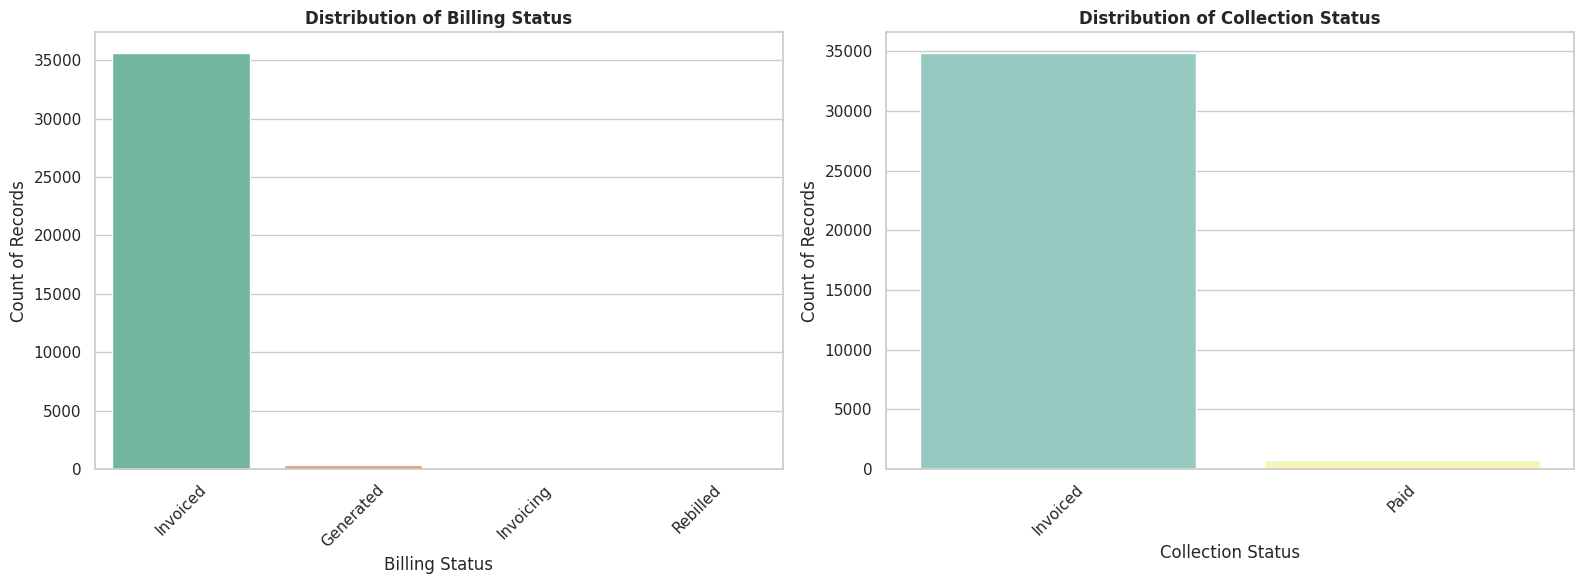

In [51]:
# 2. Operational Overview: Billing and Collection Status Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Billing Status
sns.countplot(data=combined_df, x='billing_status', hue='billing_status', ax=axes[0], palette='Set2',
              order=combined_df['billing_status'].value_counts().index, legend=False)
axes[0].set_title('Distribution of Billing Status', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count of Records')
axes[0].set_xlabel('Billing Status')

# Collection Status
sns.countplot(data=combined_df, x='collection_status', hue='collection_status', ax=axes[1], palette='Set3',
              order=combined_df['collection_status'].value_counts().index, legend=False)
axes[1].set_title('Distribution of Collection Status', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Count of Records')
axes[1].set_xlabel('Collection Status')

plt.tight_layout()
plt.show()

## 23. Gold Layer: Frequency Distributions
Let's explore the geographic distribution of our records. We will visualize the frequency of records at both the broader **Region** level and the more granular **District** level.

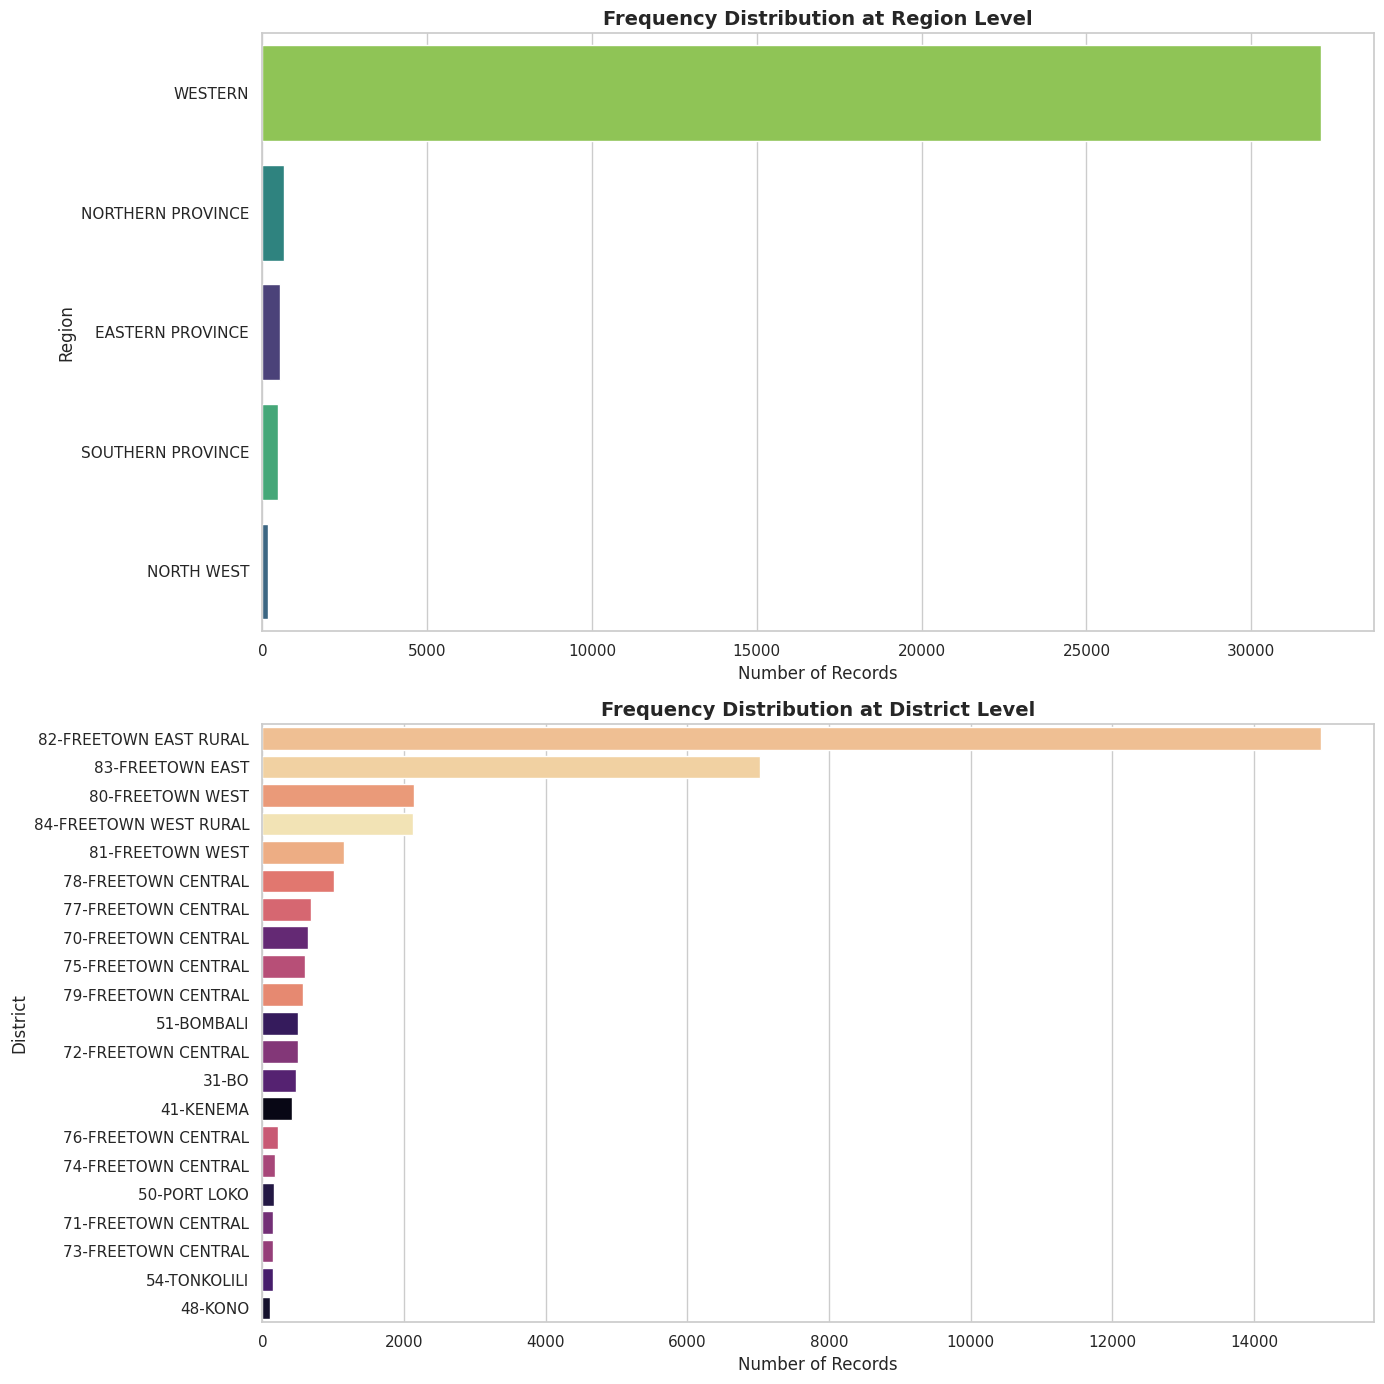

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size to accommodate both charts comfortably
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
sns.set_theme(style="whitegrid")

# 1. Frequency Distribution at the Region Level
sns.countplot(data=combined_df, y='region', hue='region', ax=axes[0], palette='viridis',
              order=combined_df['region'].value_counts().index, legend=False)
axes[0].set_title('Frequency Distribution at Region Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Records', fontsize=12)
axes[0].set_ylabel('Region', fontsize=12)

# 2. Frequency Distribution at the District Level
sns.countplot(data=combined_df, y='district', hue='district', ax=axes[1], palette='magma',
              order=combined_df['district'].value_counts().index, legend=False)
axes[1].set_title('Frequency Distribution at District Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Records', fontsize=12)
axes[1].set_ylabel('District', fontsize=12)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

## 24. Invoicing and Payment Analysis (Dark Theme)
Analyzing the proportion of invoiced customers with valid invoice numbers who have completed their payments versus those who haven't, using our custom dark and emissive red aesthetic.

========== INVOICING & PAYMENT SUMMARY ==========
Total Invoiced Records (with Invoice #): 33,595
  - Total Paid:   723 (2.2%)
  - Total Unpaid: 32,872 (97.8%)


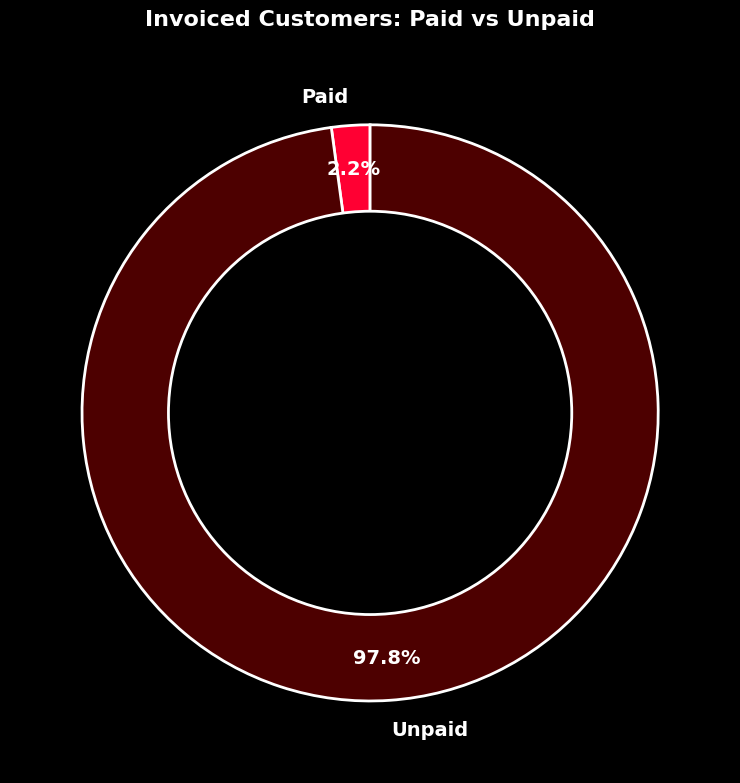

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter for Invoiced customers who actually have an invoice number
# We check that billing_status is 'Invoiced' and invoice# is not null/empty
invoiced_mask = (combined_df['billing_status'].astype(str).str.strip().str.lower() == 'invoiced') & \
                (combined_df['invoice#'].notna()) & \
                (combined_df['invoice#'].astype(str).str.strip() != '')

invoiced_df = combined_df[invoiced_mask]
total_invoiced = len(invoiced_df)

# 2. Determine Paid vs Unpaid statuses
# We will check the collection_status for 'Paid'
paid_mask = invoiced_df['collection_status'].astype(str).str.strip().str.title() == 'Paid'
paid_count = paid_mask.sum()
unpaid_count = total_invoiced - paid_count

# Print the text summary
print("========== INVOICING & PAYMENT SUMMARY ==========")
print(f"Total Invoiced Records (with Invoice #): {total_invoiced:,}")
print(f"  - Total Paid:   {paid_count:,} ({(paid_count/total_invoiced)*100:.1f}%)")
print(f"  - Total Unpaid: {unpaid_count:,} ({(unpaid_count/total_invoiced)*100:.1f}%)")

# 3. Visualization: Doughnut Chart with Custom Styling
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')

# Data for the doughnut chart
labels = ['Paid', 'Unpaid']
sizes = [paid_count, unpaid_count]

# Emissive Red color palette (Bright neon red for Paid, dark dim red for Unpaid)
colors = ['#FF0033', '#4D0000']

# Create the pie chart with white borders
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    textprops={'color': 'white', 'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Draw a black center circle to convert the pie into a doughnut
centre_circle = plt.Circle((0,0), 0.70, fc='black', edgecolor='white', linewidth=2)
fig.gca().add_artist(centre_circle)

# Add custom title
ax.set_title('Invoiced Customers: Paid vs Unpaid', color='white', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 25. Overall Invoicing Status (Dark Theme Pie Chart)
Visualizing the percentage of all records that have been successfully invoiced versus those that are still in other states (e.g., Generated, Invoicing, Rebilled).

========== OVERALL BILLING STATUS SUMMARY ==========
Total Records: 36,037
  - Invoiced: 35,607 (98.8%)
  - Other Statuses: 430 (1.2%)


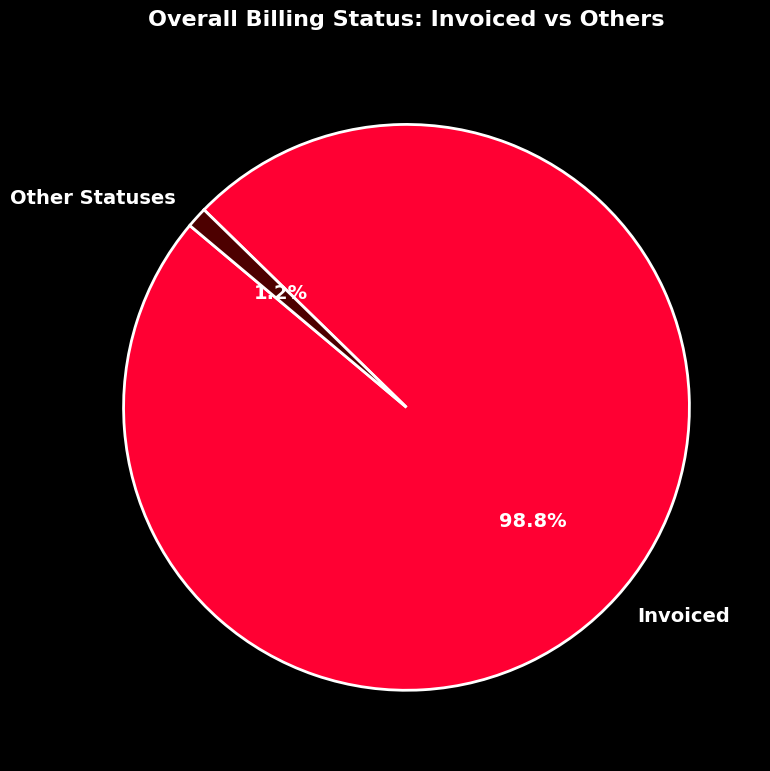

In [54]:
import matplotlib.pyplot as plt

# 1. Calculate Invoiced vs Other statuses
# Standardize text to title case for accurate counting
clean_status = combined_df['billing_status'].astype(str).str.strip().str.title()

total_records = len(combined_df)
invoiced_count = (clean_status == 'Invoiced').sum()
other_count = total_records - invoiced_count

# Print the text summary
print("========== OVERALL BILLING STATUS SUMMARY ==========")
print(f"Total Records: {total_records:,}")
print(f"  - Invoiced: {invoiced_count:,} ({(invoiced_count/total_records)*100:.1f}%)")
print(f"  - Other Statuses: {other_count:,} ({(other_count/total_records)*100:.1f}%)")

# 2. Visualization: Pie Chart with Custom Styling
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')

# Data for the pie chart
labels = ['Invoiced', 'Other Statuses']
sizes = [invoiced_count, other_count]

# Emissive Red color palette
colors = ['#FF0033', '#4D0000']

# Create the pie chart with white borders
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140, # Rotated slightly for a better visual angle
    textprops={'color': 'white', 'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Add custom title
ax.set_title('Overall Billing Status: Invoiced vs Others', color='white', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 26. Unpaid Monetary Value Analysis
Let's analyze the actual financial impact of the unpaid invoices by looking at the `pending_amount`. We will visualize the overall unpaid monetary value, and then break this down by Region and District.

========== UNPAID MONETARY VALUE SUMMARY ==========
Total Billed Value (Invoiced): 3,460,760.44
Total Unpaid Value:            3,430,920.18


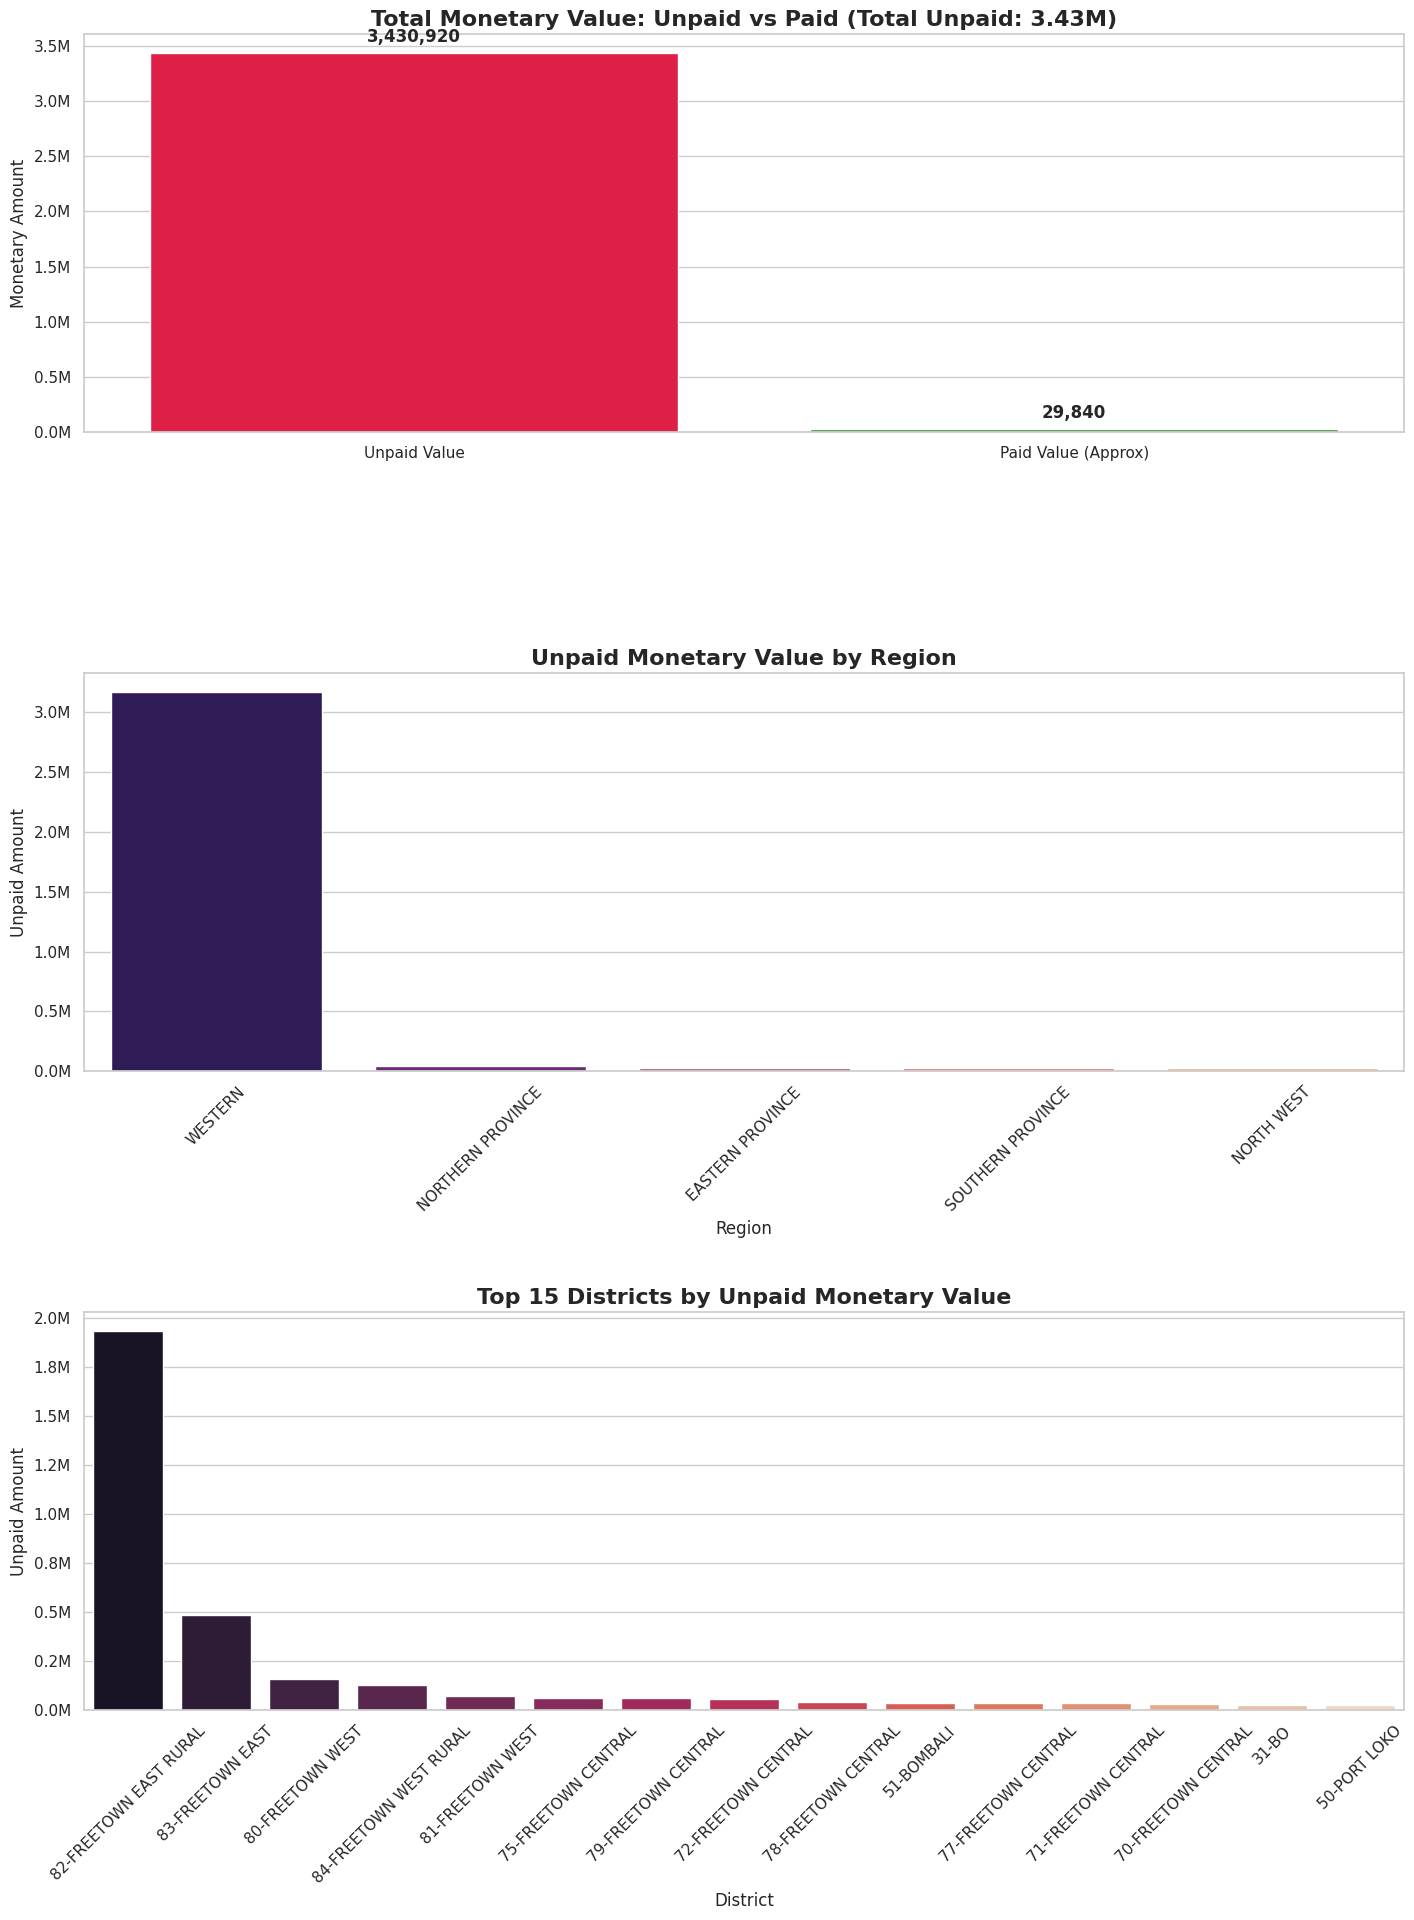

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Prepare Unpaid Data
# Filter for records that are 'Invoiced' but NOT 'Paid'
is_invoiced = combined_df['billing_status'].astype(str).str.strip().str.title() == 'Invoiced'
is_not_paid = combined_df['collection_status'].astype(str).str.strip().str.title() != 'Paid'
unpaid_df = combined_df[is_invoiced & is_not_paid]

# Calculate totals
total_unpaid_value = unpaid_df['pending_amount'].sum()
total_billed_value = combined_df.loc[is_invoiced, 'total_amount'].sum()

print("========== UNPAID MONETARY VALUE SUMMARY ==========")
print(f"Total Billed Value (Invoiced): {total_billed_value:,.2f}")
print(f"Total Unpaid Value:            {total_unpaid_value:,.2f}")

# 2. Visualizations
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(15, 20))

# --- Plot 1: Overall Monetary Value (Unpaid vs Paid) ---
ax1 = plt.subplot(3, 1, 1)
# Approximate paid as total billed minus unpaid pending
status_vals = ['Unpaid Value', 'Paid Value (Approx)']
amounts = [total_unpaid_value, total_billed_value - total_unpaid_value]
sns.barplot(x=status_vals, y=amounts, palette=['#FF0033', '#2ca02c'], ax=ax1, hue=status_vals, legend=False)
ax1.set_title(f'Total Monetary Value: Unpaid vs Paid (Total Unpaid: {total_unpaid_value/1e6:,.2f}M)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Monetary Amount')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

# Add value labels on top of the bars
for i, v in enumerate(amounts):
    ax1.text(i, v + (max(amounts)*0.02), f'{v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# --- Plot 2: Unpaid Value by Region ---
ax2 = plt.subplot(3, 1, 2)
region_unpaid = unpaid_df.groupby('region')['pending_amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=region_unpaid, x='region', y='pending_amount', palette='magma', ax=ax2, hue='region', legend=False)
ax2.set_title('Unpaid Monetary Value by Region', fontsize=16, fontweight='bold')
ax2.set_ylabel('Unpaid Amount')
ax2.set_xlabel('Region')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))
ax2.tick_params(axis='x', rotation=45)

# --- Plot 3: Unpaid Value by District (Top 15) ---
ax3 = plt.subplot(3, 1, 3)
district_unpaid = unpaid_df.groupby('district')['pending_amount'].sum().sort_values(ascending=False).head(15).reset_index()
sns.barplot(data=district_unpaid, x='district', y='pending_amount', palette='rocket', ax=ax3, hue='district', legend=False)
ax3.set_title('Top 15 Districts by Unpaid Monetary Value', fontsize=16, fontweight='bold')
ax3.set_ylabel('Unpaid Amount')
ax3.set_xlabel('District')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

plt.tight_layout(pad=3.0)
plt.show()


## 27. Monetary Value: Unpaid vs Paid (%)
Let's visualize the exact percentage of the monetary value that remains unpaid compared to what has been collected, using a dark-themed doughnut chart.

========== MONETARY VALUE PERCENTAGE SUMMARY ==========
Total Billed Value: 3,460,760.44
  - Unpaid Value:   3,430,920.18 (99.1%)
  - Paid Value:     29,840.26 (0.9%)


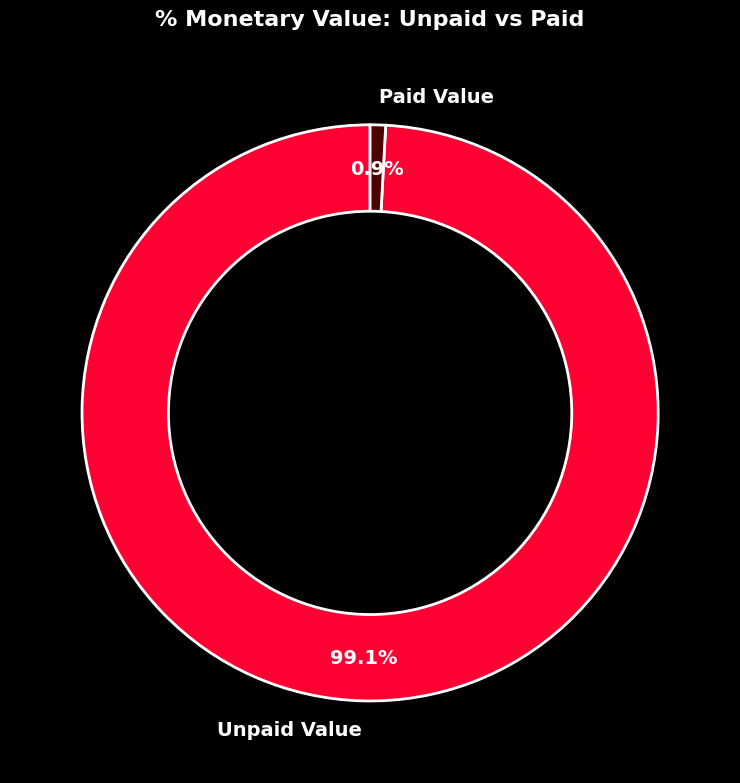

In [56]:
import matplotlib.pyplot as plt

# 1. Calculate values
# Re-using the logic to ensure standalone execution
is_invoiced = combined_df['billing_status'].astype(str).str.strip().str.title() == 'Invoiced'
is_not_paid = combined_df['collection_status'].astype(str).str.strip().str.title() != 'Paid'
unpaid_df = combined_df[is_invoiced & is_not_paid]

total_unpaid_value = unpaid_df['pending_amount'].sum()
total_billed_value = combined_df.loc[is_invoiced, 'total_amount'].sum()
total_paid_value = total_billed_value - total_unpaid_value

# Handle case where total_billed_value is 0 to avoid division by zero
if total_billed_value > 0:
    unpaid_pct = (total_unpaid_value / total_billed_value) * 100
    paid_pct = (total_paid_value / total_billed_value) * 100
else:
    unpaid_pct = 0
    paid_pct = 0

print("========== MONETARY VALUE PERCENTAGE SUMMARY ==========")
print(f"Total Billed Value: {total_billed_value:,.2f}")
print(f"  - Unpaid Value:   {total_unpaid_value:,.2f} ({unpaid_pct:.1f}%)")
print(f"  - Paid Value:     {total_paid_value:,.2f} ({paid_pct:.1f}%)")

# 2. Visualization: Doughnut Chart with Custom Styling
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')

# Data for the pie chart
labels = ['Unpaid Value', 'Paid Value']
sizes = [total_unpaid_value, total_paid_value]

# Emissive Red color palette (Bright red for the dominant Unpaid issue, dark red for Paid)
colors = ['#FF0033', '#4D0000']

# Create the pie chart with white borders
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    textprops={'color': 'white', 'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Draw a black center circle to convert the pie into a doughnut
centre_circle = plt.Circle((0,0), 0.70, fc='black', edgecolor='white', linewidth=2)
fig.gca().add_artist(centre_circle)

# Add custom title
ax.set_title('% Monetary Value: Unpaid vs Paid', color='white', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 28. Invoiced Records: Financial Data Anomalies Analysis
Let's analyze the invoiced records specifically to identify how many have missing or zero values in critical financial and consumption fields.

========== INVOICED RECORDS FINANCIAL DATA ANOMALIES ==========
Total Invoiced Records: 35,607

1. Missing Values in Fields:
   - Total Amount empty: 8,849
   - Pending Amount empty: 8,341
   - Billed Consumption empty: 6,961

2. Total/Pending is 0 OR Consumption is empty: 7,339
3. BOTH Total and Pending are empty: 8,341
4. ALL 3 (Total, Pending, Consumption) are empty: 6,509



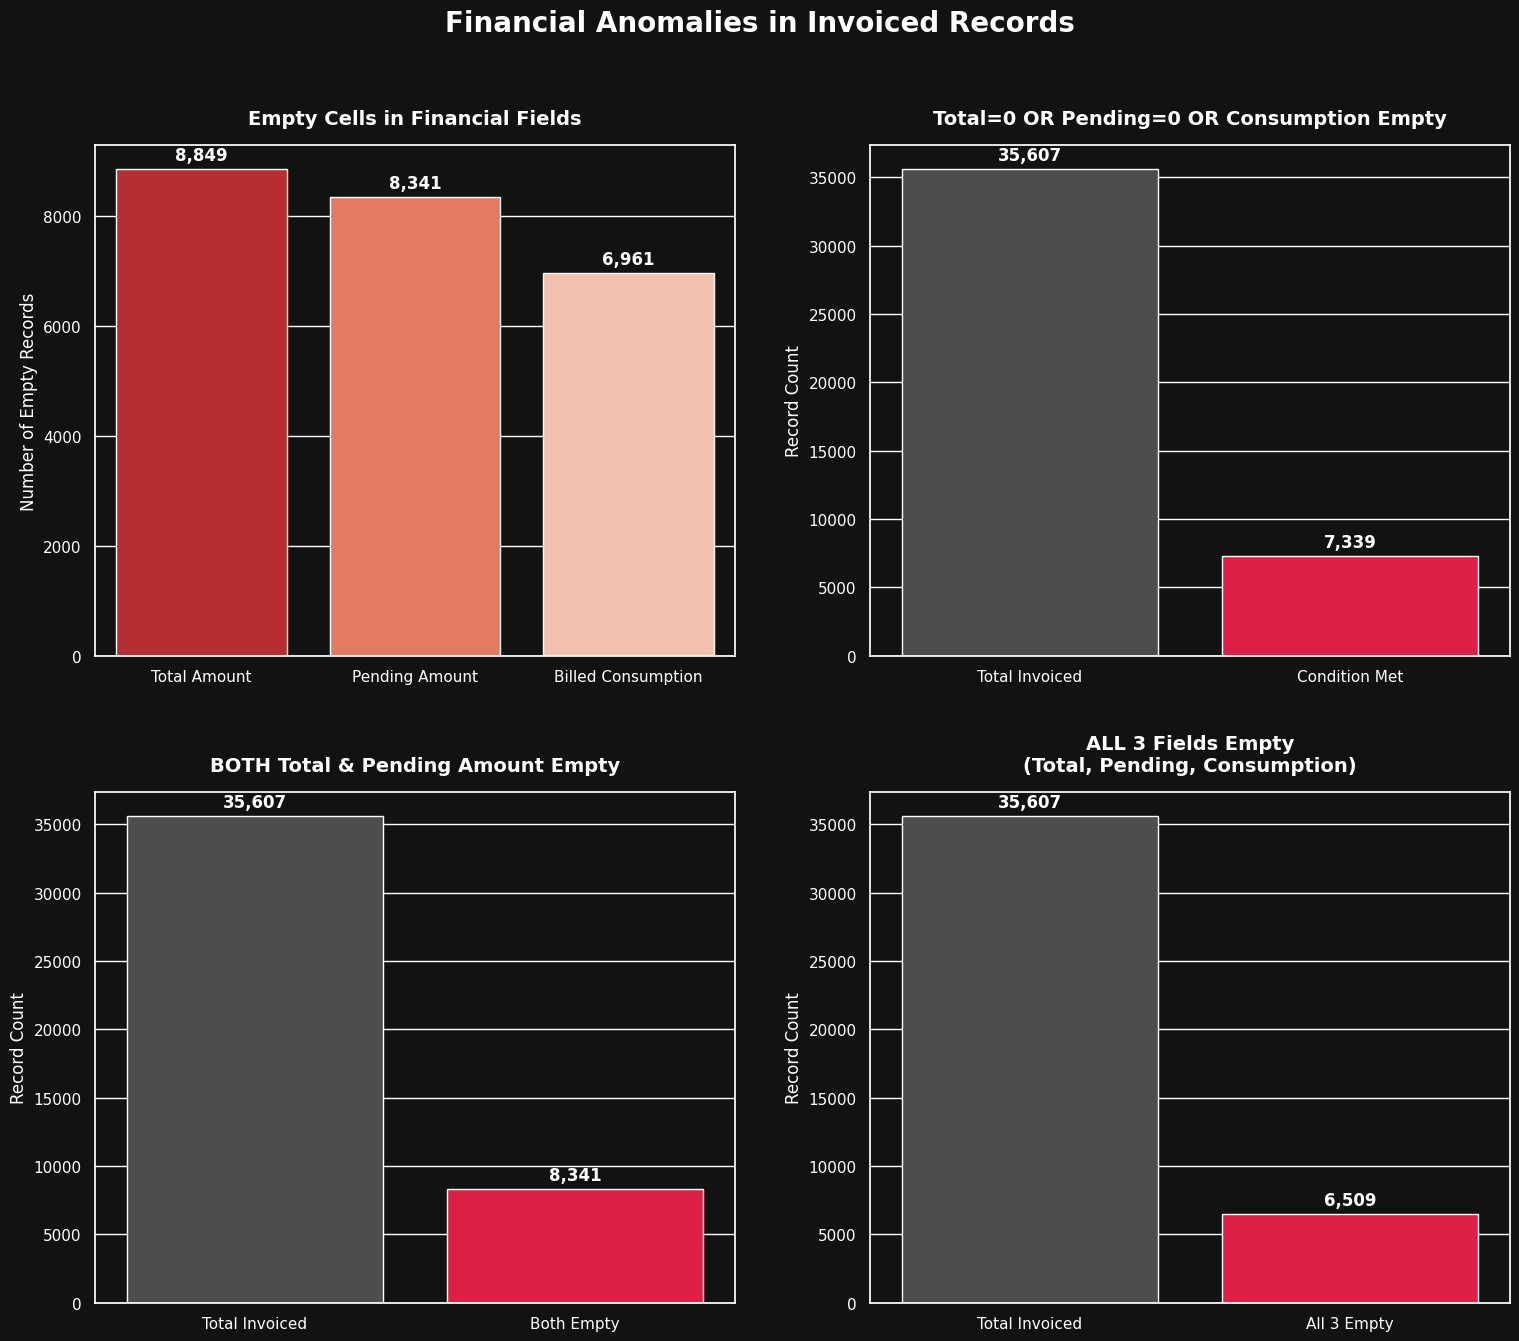

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for Invoiced records
is_invoiced = combined_df['billing_status'].astype(str).str.strip().str.title() == 'Invoiced'
df_inv = combined_df[is_invoiced]
total_inv_count = len(df_inv)

# 2. Calculate requested metrics
# Q1: Empty cells in the 3 fields
missing_total = df_inv['total_amount'].isna().sum()
missing_pending = df_inv['pending_amount'].isna().sum()
missing_consumption = df_inv['billed_consumption'].isna().sum()

# Q2: Total == 0 OR Pending == 0 OR Consumption is NaN
cond_a = (df_inv['total_amount'] == 0) | (df_inv['pending_amount'] == 0) | df_inv['billed_consumption'].isna()
count_cond_a = cond_a.sum()

# Q3: Both Total AND Pending are NaN
cond_b = df_inv['total_amount'].isna() & df_inv['pending_amount'].isna()
count_cond_b = cond_b.sum()

# Q4: All 3 (Total, Pending, Consumption) are NaN
cond_c = df_inv['total_amount'].isna() & df_inv['pending_amount'].isna() & df_inv['billed_consumption'].isna()
count_cond_c = cond_c.sum()

# Print summary
print("========== INVOICED RECORDS FINANCIAL DATA ANOMALIES ==========")
print(f"Total Invoiced Records: {total_inv_count:,}\n")
print("1. Missing Values in Fields:")
print(f"   - Total Amount empty: {missing_total:,}")
print(f"   - Pending Amount empty: {missing_pending:,}")
print(f"   - Billed Consumption empty: {missing_consumption:,}\n")
print(f"2. Total/Pending is 0 OR Consumption is empty: {count_cond_a:,}")
print(f"3. BOTH Total and Pending are empty: {count_cond_b:,}")
print(f"4. ALL 3 (Total, Pending, Consumption) are empty: {count_cond_c:,}\n")

# 3. Visualizations (Dark Theme)
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Helper function to add labels
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, color='white', xytext=(0, 10),
                    textcoords='offset points', fontweight='bold')

# Plot 1: Missing Values in Fields
ax1 = axes[0, 0]
sns.barplot(x=['Total Amount', 'Pending Amount', 'Billed Consumption'], y=[missing_total, missing_pending, missing_consumption], palette='Reds_r', ax=ax1, hue=['Total Amount', 'Pending Amount', 'Billed Consumption'], legend=False)
ax1.set_title('Empty Cells in Financial Fields', fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_ylabel('Number of Empty Records')
add_labels(ax1)

# Plot 2: Total=0 OR Pending=0 OR Consumption=NaN
ax2 = axes[0, 1]
sns.barplot(x=['Total Invoiced', 'Condition Met'], y=[total_inv_count, count_cond_a], palette=['#4D4D4D', '#FF0033'], ax=ax2, hue=['Total Invoiced', 'Condition Met'], legend=False)
ax2.set_title('Total=0 OR Pending=0 OR Consumption Empty', fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_ylabel('Record Count')
add_labels(ax2)

# Plot 3: Both Total and Pending empty
ax3 = axes[1, 0]
sns.barplot(x=['Total Invoiced', 'Both Empty'], y=[total_inv_count, count_cond_b], palette=['#4D4D4D', '#FF0033'], ax=ax3, hue=['Total Invoiced', 'Both Empty'], legend=False)
ax3.set_title('BOTH Total & Pending Amount Empty', fontsize=14, fontweight='bold', color='white', pad=15)
ax3.set_ylabel('Record Count')
add_labels(ax3)

# Plot 4: All 3 empty
ax4 = axes[1, 1]
sns.barplot(x=['Total Invoiced', 'All 3 Empty'], y=[total_inv_count, count_cond_c], palette=['#4D4D4D', '#FF0033'], ax=ax4, hue=['Total Invoiced', 'All 3 Empty'], legend=False)
ax4.set_title('ALL 3 Fields Empty\n(Total, Pending, Consumption)', fontsize=14, fontweight='bold', color='white', pad=15)
ax4.set_ylabel('Record Count')
add_labels(ax4)

plt.suptitle('Financial Anomalies in Invoiced Records', fontsize=20, fontweight='bold', color='white', y=0.98)
plt.tight_layout(pad=3.0)
plt.show()

# Reset theme to default for future plots if needed
sns.reset_orig()


## 29. Telemetry Data Construction
To enable time-series analysis (tracking individual customer behavior over time), we will construct a telemetry-style dataset. We will use `account#` as the unique identifier and `billing_period` as the temporal index, capturing core usage and financial metrics at each timestamp.

========== TELEMETRY DATASET READY ==========
Telemetry Records: 33,930
Unique Accounts Tracked: 3,573


,account#,billing_period,billed_consumption,total_amount,pending_amount,billing_status,collection_status
30369,1000001131,2025-06-01,24.0,129.47,129.47,Invoiced,Invoiced
20472,1000001131,2025-07-01,141.0,697.27,697.27,Invoiced,Invoiced
824,1000001131,2025-08-01,88.0,440.06,440.06,Invoiced,Invoiced
12318,1000001131,2025-09-01,62.0,313.89,313.89,Invoiced,Invoiced
33564,1000001131,2025-10-01,90.0,449.77,449.77,Invoiced,Invoiced


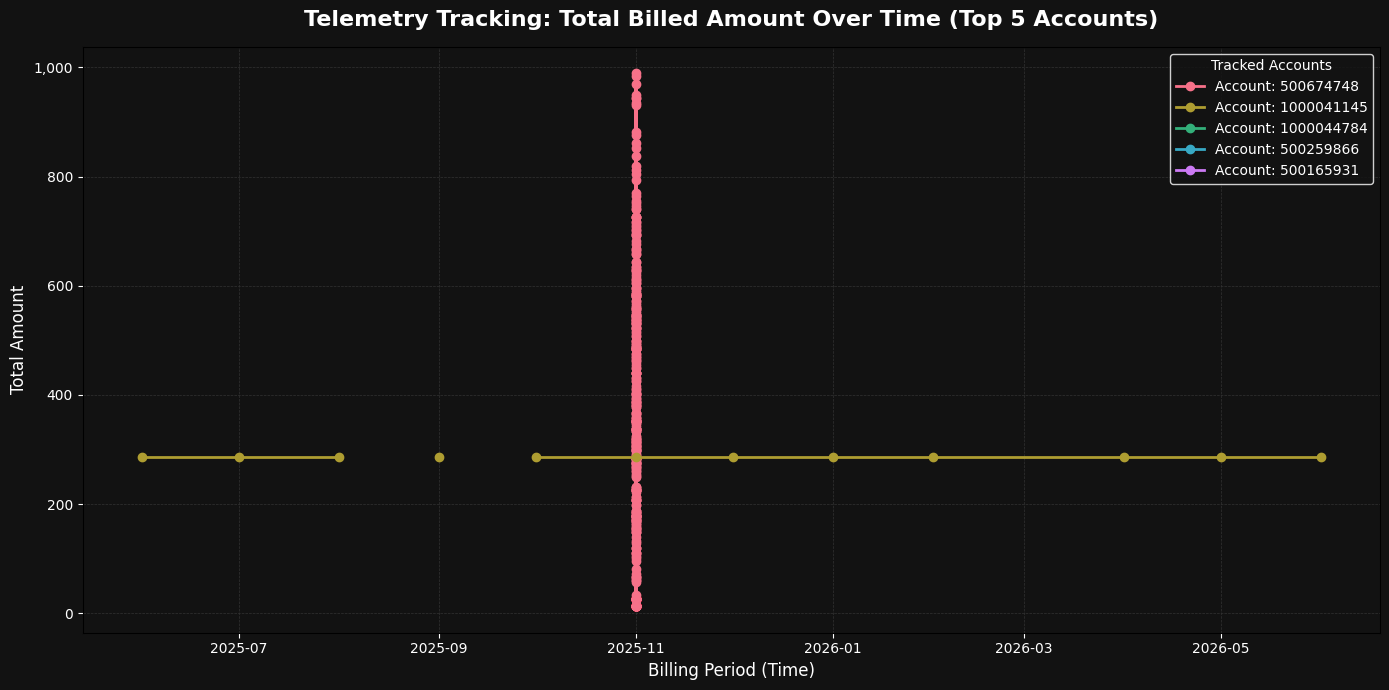

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Construct Telemetry DataFrame
# Select the columns that matter for tracking over time
telemetry_cols = ['account#', 'billing_period', 'billed_consumption', 'total_amount', 'pending_amount', 'billing_status', 'collection_status']

# Drop rows where we can't identify the account or time
telemetry_df = combined_df.dropna(subset=['account#', 'billing_period'])[telemetry_cols].copy()

# Ensure billing_period is a datetime object for proper time-series plotting
telemetry_df['billing_period'] = pd.to_datetime(telemetry_df['billing_period'], errors='coerce')
telemetry_df = telemetry_df.dropna(subset=['billing_period'])

# Sort chronologically by Account then by Date
telemetry_df = telemetry_df.sort_values(by=['account#', 'billing_period'])

print("========== TELEMETRY DATASET READY ==========")
print(f"Telemetry Records: {len(telemetry_df):,}")
print(f"Unique Accounts Tracked: {telemetry_df['account#'].nunique():,}")
display(telemetry_df.head())

# 2. Telemetry Visualization (Sample Tracking)
# Let's pick the 5 accounts with the most billing periods recorded to show their trend
top_accounts = telemetry_df['account#'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#121212')
ax.set_facecolor('#121212')

# Color palette for the lines
colors = sns.color_palette("husl", len(top_accounts))

for idx, account in enumerate(top_accounts):
    acct_data = telemetry_df[telemetry_df['account#'] == account]
    ax.plot(acct_data['billing_period'], acct_data['total_amount'],
             marker='o', label=f'Account: {account}', linewidth=2, color=colors[idx])

# Styling
ax.set_title('Telemetry Tracking: Total Billed Amount Over Time (Top 5 Accounts)', color='white', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Billing Period (Time)', color='white', fontsize=12)
ax.set_ylabel('Total Amount', color='white', fontsize=12)

ax.tick_params(colors='white')
ax.grid(color='#333333', linestyle='--', linewidth=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

legend = ax.legend(facecolor='#121212', edgecolor='white', title='Tracked Accounts')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

plt.tight_layout()
plt.show()


## 30. Telemetry Dataset Export
Let's export the newly constructed telemetry dataset to a CSV file for future time-series analysis.

In [59]:
import os

# Define the output path for the telemetry dataset
telemetry_output_filename = 'telemetry_postpaid_data.csv'
telemetry_output_path = os.path.join(target_dir, telemetry_output_filename)

# Export the telemetry DataFrame to CSV
telemetry_df.to_csv(telemetry_output_path, index=False)
print(f"Telemetry dataset successfully exported to: {telemetry_output_path}")


Telemetry dataset successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/telemetry_postpaid_data.csv


## 31. Telemetry Tracking: All Accounts Over Time
Visualizing the `total_amount` across time for all 3,573 unique accounts in a single plot. Due to the high volume of lines, we use a low opacity (alpha) to highlight density and outliers rather than individual lines.

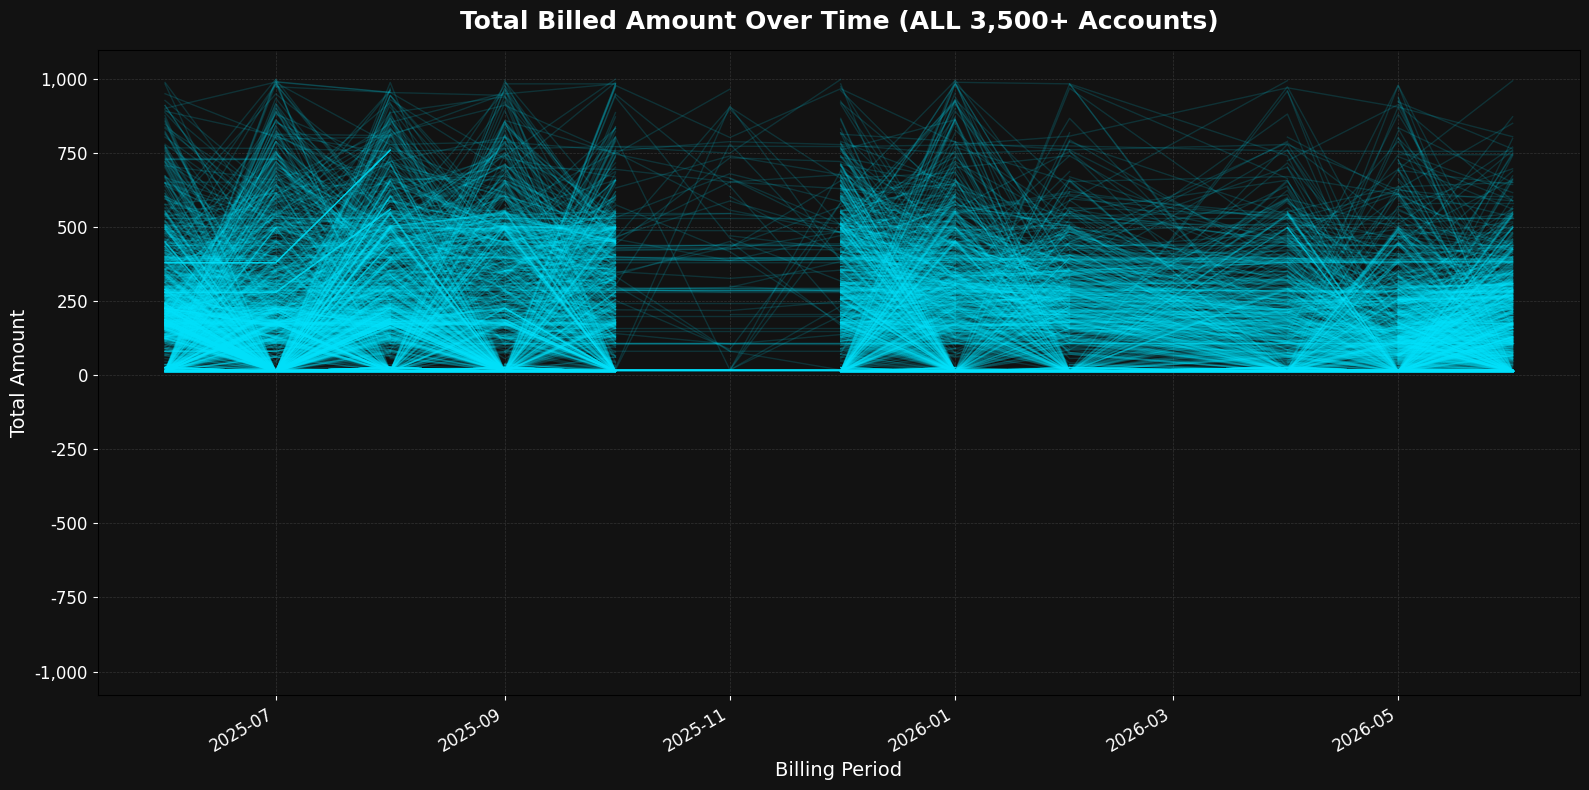

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Pivot the telemetry data to make plotting all accounts much faster
# Index: Time (billing_period), Columns: Accounts, Values: total_amount
pivot_df = telemetry_df.pivot_table(index='billing_period', columns='account#', values='total_amount')

# Set up the plot with the dark theme
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#121212')
ax.set_facecolor('#121212')

# Plot all accounts. We disable the legend because 3,500+ items would crash it.
# We use alpha=0.15 so overlapping lines create brighter, denser areas.
pivot_df.plot(ax=ax, legend=False, alpha=0.15, linewidth=1, color='#00E5FF')

# Styling
ax.set_title('Total Billed Amount Over Time (ALL 3,500+ Accounts)', color='white', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Billing Period', color='white', fontsize=14)
ax.set_ylabel('Total Amount', color='white', fontsize=14)

ax.tick_params(colors='white', labelsize=12)
ax.grid(color='#333333', linestyle='--', linewidth=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


## 32. Investigating the Chart Gap
Let's check the number of valid `total_amount` entries and the total number of records for each `billing_period` to see if a specific month is missing data.

In [61]:
# Count total records and valid total_amounts per billing_period
gap_analysis = telemetry_df.groupby('billing_period').agg(
    total_records=('account#', 'size'),
    valid_amounts=('total_amount', 'count'),
    missing_amounts=('total_amount', lambda x: x.isna().sum())
).reset_index()

# Display the results sorted chronologically
display(gap_analysis)


,billing_period,total_records,valid_amounts,missing_amounts
0,2025-06-01,3184,2472,712
1,2025-07-01,3199,2460,739
2,2025-08-01,2915,2217,698
3,2025-09-01,2596,1875,721
4,2025-10-01,3391,2679,712
5,2025-11-01,1772,1109,663
6,2025-12-01,2778,2079,699
7,2026-01-01,2756,2088,668
8,2026-02-01,2604,1945,659
9,2026-03-01,1,0,1


## 33. Telemetry Tracking: Zero-Consumption Accounts
Identifying accounts that reported exactly `0` billed consumption in at least one billing period, and visualizing their consumption trends over time.

Total unique accounts with at least one '0' billed consumption: 2,629


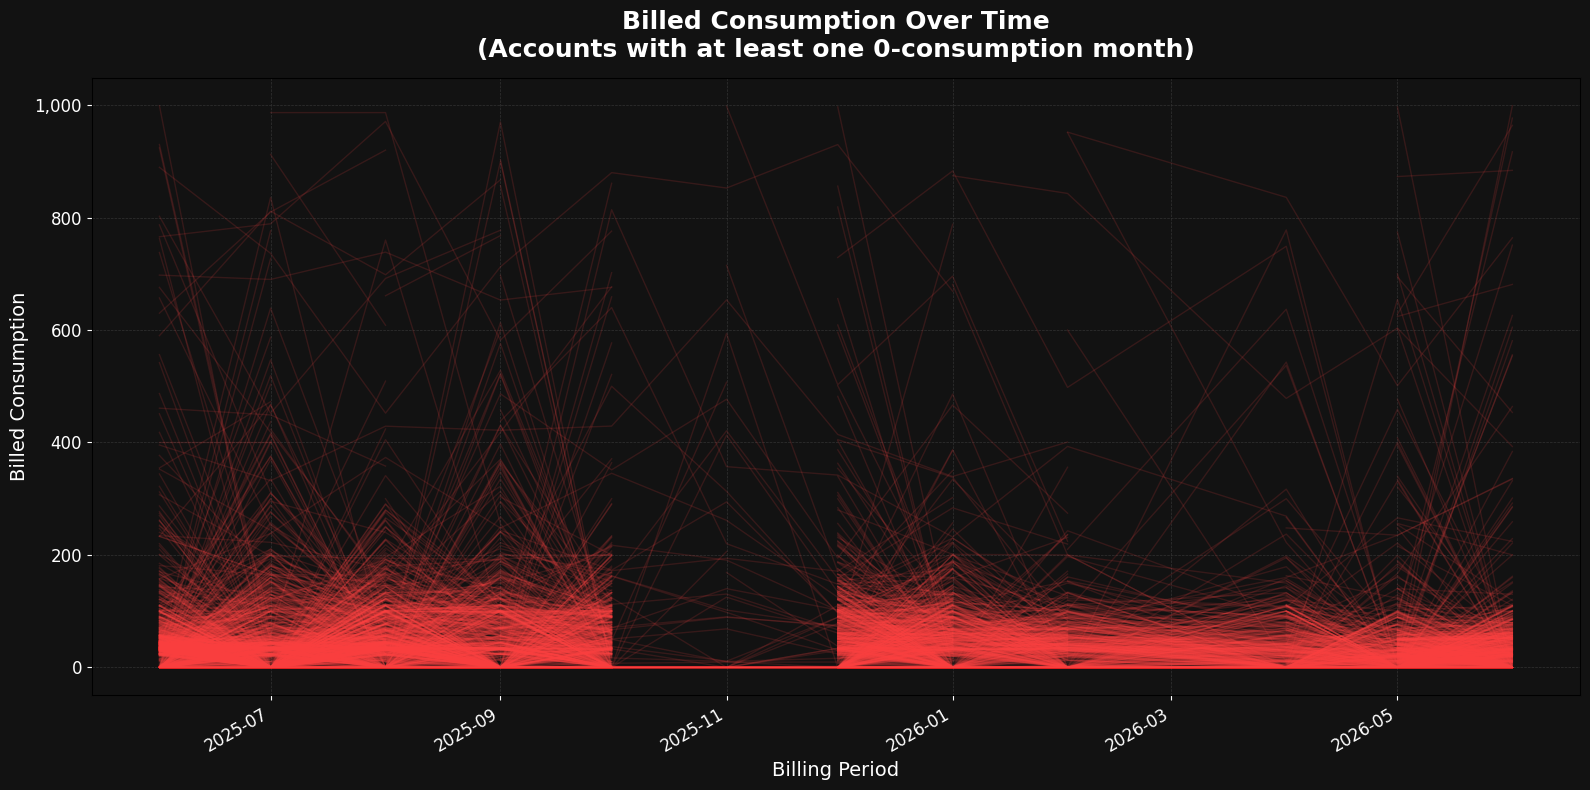

In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Identify accounts with at least one month of exactly 0 billed consumption
zero_cons_accounts = telemetry_df[telemetry_df['billed_consumption'] == 0]['account#'].unique()
print(f"Total unique accounts with at least one '0' billed consumption: {len(zero_cons_accounts):,}")

# 2. Filter the telemetry data for only these accounts
zero_cons_df = telemetry_df[telemetry_df['account#'].isin(zero_cons_accounts)]

# 3. Pivot the data for plotting (Time as index, Accounts as columns, Billed Consumption as values)
pivot_zero = zero_cons_df.pivot_table(index='billing_period', columns='account#', values='billed_consumption')

# 4. Plotting
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#121212')
ax.set_facecolor('#121212')

# Plot lines with low opacity. We use a red hue to distinguish this specific subset.
pivot_zero.plot(ax=ax, legend=False, alpha=0.15, linewidth=1, color='#FF4444')

# Styling
ax.set_title('Billed Consumption Over Time\n(Accounts with at least one 0-consumption month)', color='white', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Billing Period', color='white', fontsize=14)
ax.set_ylabel('Billed Consumption', color='white', fontsize=14)

ax.tick_params(colors='white', labelsize=12)
ax.grid(color='#333333', linestyle='--', linewidth=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


## 34. Telemetry Tracking: Zero-Consumption Accounts (Revised)
Re-plotting the consumption trends for the zero-consumption accounts, but this time explicitly filtering out the anomalous **March 2026** billing period to eliminate the visual gap in our time series.

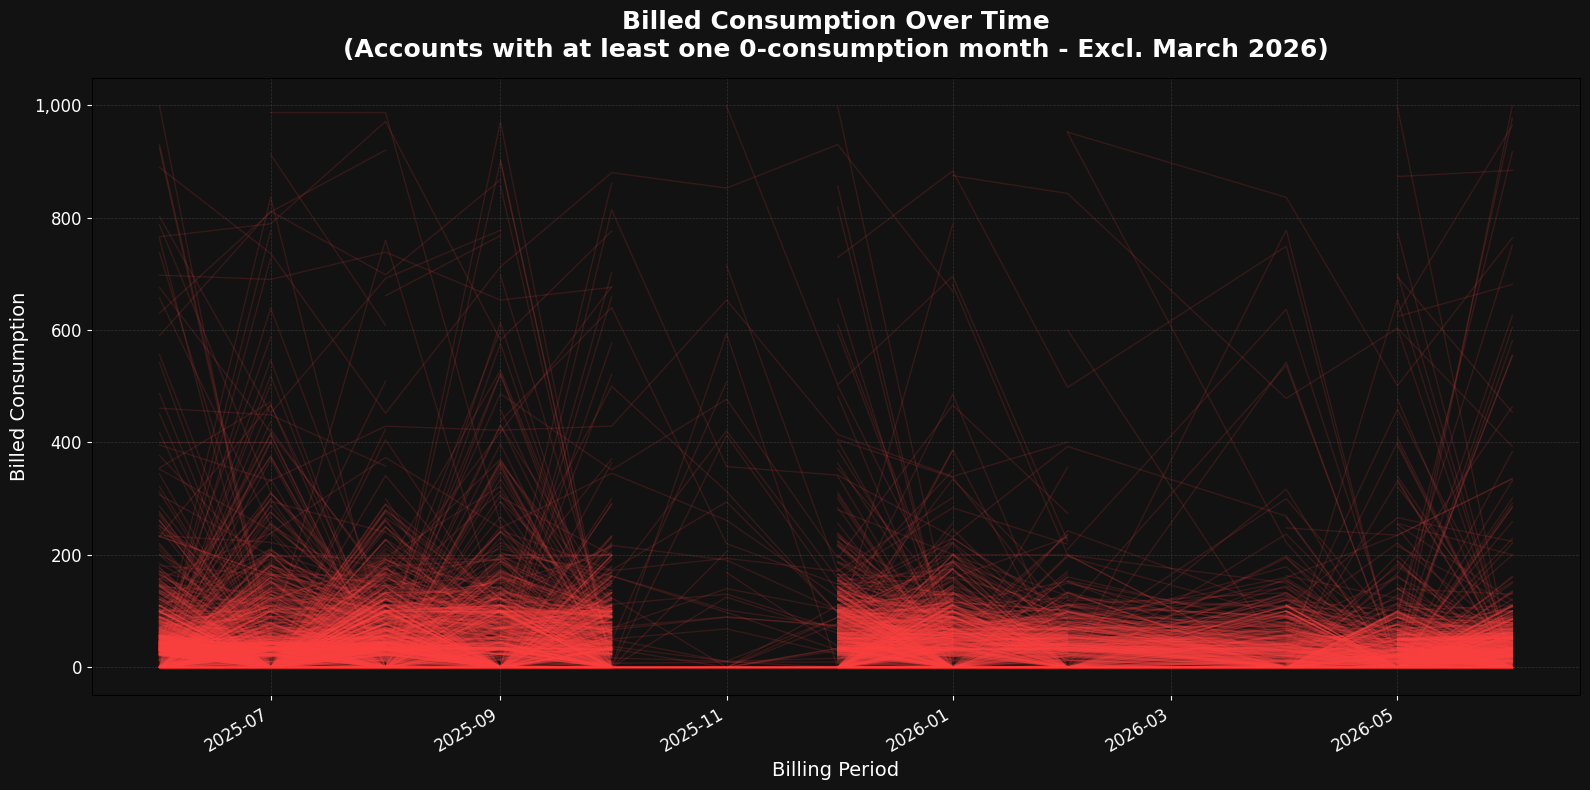

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. Filter out March 2026 (2026-03-01) from our zero-consumption DataFrame
missing_month = pd.to_datetime('2026-03-01')
zero_cons_df_filtered = zero_cons_df[zero_cons_df['billing_period'] != missing_month]

# 2. Pivot the filtered data
pivot_zero_filtered = zero_cons_df_filtered.pivot_table(index='billing_period', columns='account#', values='billed_consumption')

# 3. Plotting the revised chart
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#121212')
ax.set_facecolor('#121212')

# Plot lines with low opacity
pivot_zero_filtered.plot(ax=ax, legend=False, alpha=0.15, linewidth=1, color='#FF4444')

# Styling
ax.set_title('Billed Consumption Over Time\n(Accounts with at least one 0-consumption month - Excl. March 2026)', color='white', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Billing Period', color='white', fontsize=14)
ax.set_ylabel('Billed Consumption', color='white', fontsize=14)

ax.tick_params(colors='white', labelsize=12)
ax.grid(color='#333333', linestyle='--', linewidth=0.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


## 35. Comparing Zero-Consumption Accounts vs. Regular Accounts
Let's categorize our user base into two segments:
1. **Zero-Consumption History**: Accounts that reported `0` billed consumption in at least one billing period.
2. **Regular Consumption**: Accounts that have never reported a `0` billed consumption.

We will compare their overall proportion, financial impact (Total Billed Amount), and payment reliability (% Unpaid).

In [64]:
# 1. Categorize Accounts
# Identify accounts with at least one record of exactly 0 consumption
zero_cons_accts = telemetry_df[telemetry_df['billed_consumption'] == 0]['account#'].unique()

# Create a new column in telemetry_df to flag these accounts
telemetry_df['account_type'] = telemetry_df['account#'].apply(
    lambda x: 'Zero-Consumption History' if x in zero_cons_accts else 'Regular Consumption'
)

# 2. Calculate Comparative Statistics
account_stats = telemetry_df.groupby('account_type').agg(
    total_unique_accounts=('account#', 'nunique'),
    total_records=('account#', 'count'),
    total_billed_amount=('total_amount', 'sum'),
    total_pending_amount=('pending_amount', 'sum')
).reset_index()

# Calculate the unpaid percentage (Total Pending / Total Billed)
account_stats['unpaid_percentage'] = (
    account_stats['total_pending_amount'] / account_stats['total_billed_amount']
) * 100

print("========== ACCOUNT TYPE COMPARISON STATS ==========")
display(account_stats)


========== ACCOUNT TYPE COMPARISON STATS ==========


,account_type,total_unique_accounts,total_records,total_billed_amount,total_pending_amount,unpaid_percentage
0,Regular Consumption,944,9429,812879.50,809306.11,99.560403
1,Zero-Consumption History,2629,24501,2543214.09,2520692.96,99.114462


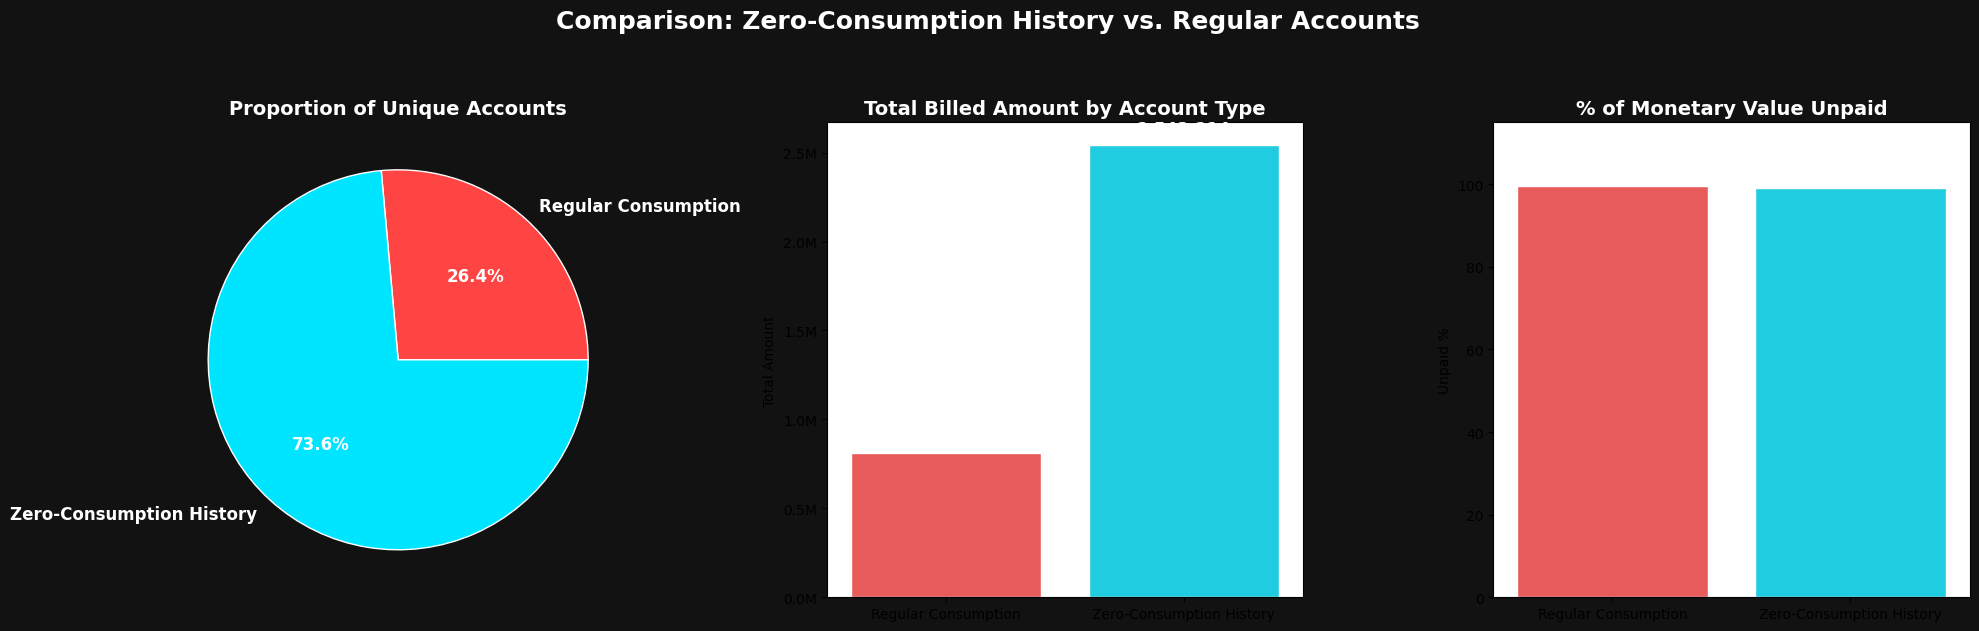

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 3. Visualizing the Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#121212')
fig.patch.set_facecolor('#121212')

# Apply a temporary dark theme for seaborn
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# Colors: Red for Zero-Consumption, Cyan for Regular
colors = ['#FF4444', '#00E5FF']

# Plot 1: Account Distribution (Pie Chart)
axes[0].pie(account_stats['total_unique_accounts'], labels=account_stats['account_type'], colors=colors, autopct='%1.1f%%',
            textprops={'color': 'white', 'fontweight': 'bold', 'fontsize': 12}, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Proportion of Unique Accounts', color='white', fontweight='bold', fontsize=14)

# Plot 2: Total Billed Amount Comparison (Bar Chart)
sns.barplot(data=account_stats, x='account_type', y='total_billed_amount', palette=colors, ax=axes[1], hue='account_type', legend=False)
axes[1].set_title('Total Billed Amount by Account Type', color='white', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Total Amount')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

# Add value labels on top of the bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='white', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Plot 3: Unpaid Percentage (Bar Chart)
sns.barplot(data=account_stats, x='account_type', y='unpaid_percentage', palette=colors, ax=axes[2], hue='account_type', legend=False)
axes[2].set_title('% of Monetary Value Unpaid', color='white', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Unpaid %')
axes[2].set_xlabel('')
axes[2].set_ylim(0, 115) # Leave room for labels

# Add percentage labels
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='white', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle('Comparison: Zero-Consumption History vs. Regular Accounts', color='white', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Reset theme to default for any future plots
sns.reset_orig()


## 36. Dormant Accounts Analysis (Consecutive Zero Consumption)
We will calculate the maximum streak of consecutive `0` billed consumption for every account. Then, we will generate independent visualizations for accounts that have been dormant for at least 3, 5, 6, 7, 8, 9, 10, 11, and 12 consecutive months.

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Calculate the maximum consecutive 0-consumption streak per account
# Ensure data is sorted chronologically
telemetry_df = telemetry_df.sort_values(by=['account#', 'billing_period'])

# Create a boolean mask for zero consumption
telemetry_df['is_zero_cons'] = (telemetry_df['billed_consumption'] == 0)

# Group by account and create blocks of consecutive identical 'is_zero_cons' values
# A new block starts whenever 'is_zero_cons' changes from True to False (or vice versa)
telemetry_df['zero_block'] = (~telemetry_df['is_zero_cons']).groupby(telemetry_df['account#']).cumsum()

# Filter to only the zero-consumption records and count the size of each block
streaks = telemetry_df[telemetry_df['is_zero_cons']].groupby(['account#', 'zero_block']).size().reset_index(name='streak_length')

# Get the maximum streak length for each account
max_streaks = streaks.groupby('account#')['streak_length'].max().reset_index()

# Create a dictionary to easily map accounts to their max streak
streak_map = dict(zip(max_streaks['account#'], max_streaks['streak_length']))

# Add the max streak back to the unique accounts list
all_unique_accounts = pd.DataFrame({'account#': telemetry_df['account#'].unique()})
all_unique_accounts['max_zero_streak'] = all_unique_accounts['account#'].map(streak_map).fillna(0)

print("Max streak calculation complete. Ready to plot.")


Max streak calculation complete. Ready to plot.


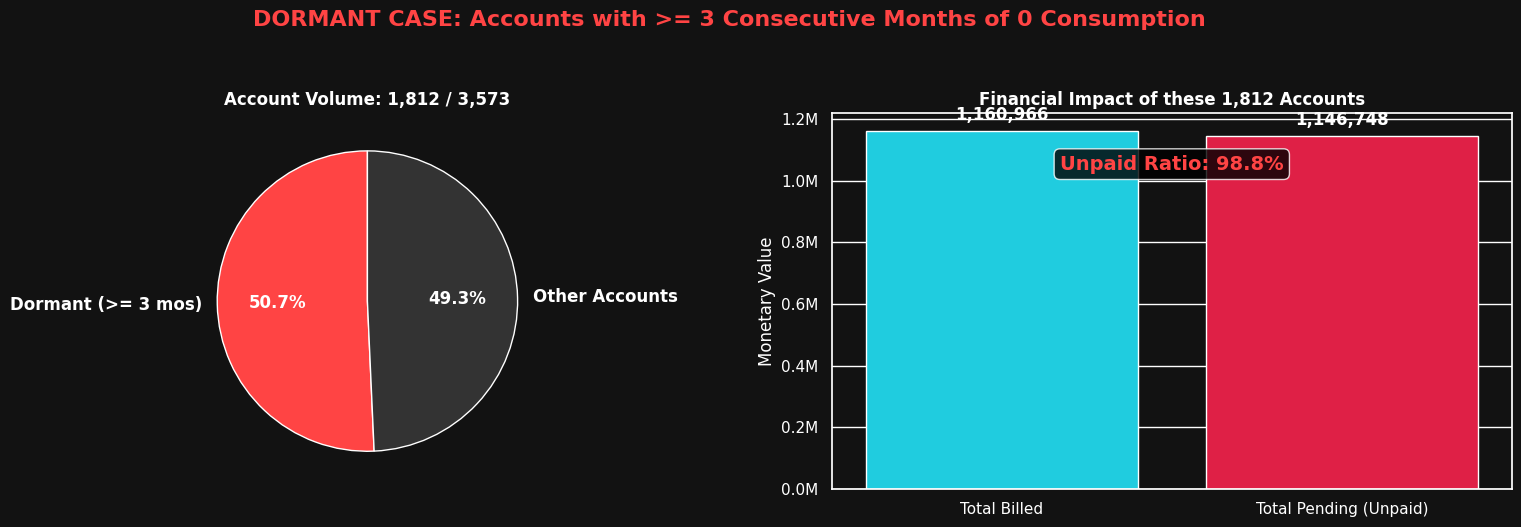

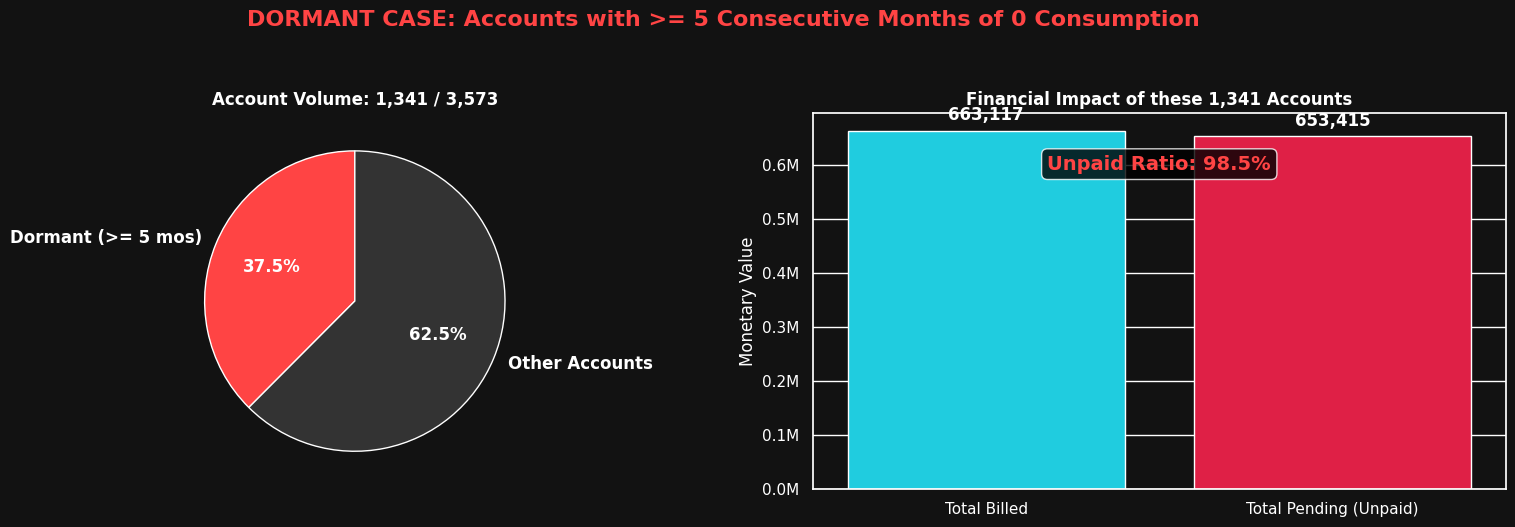

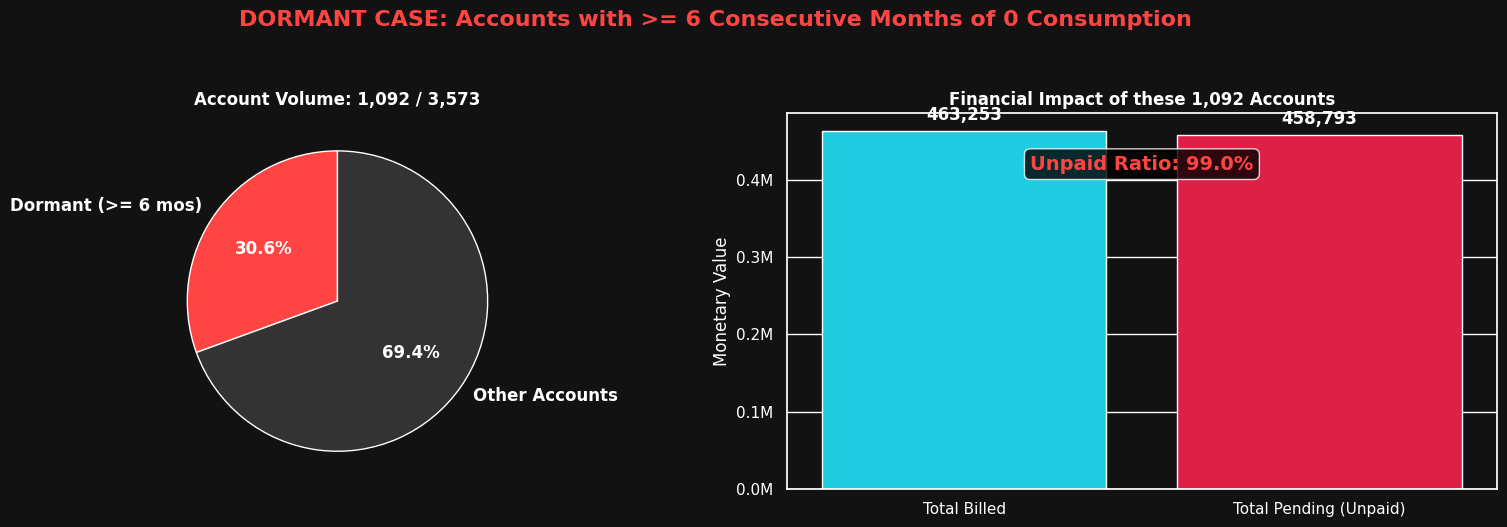

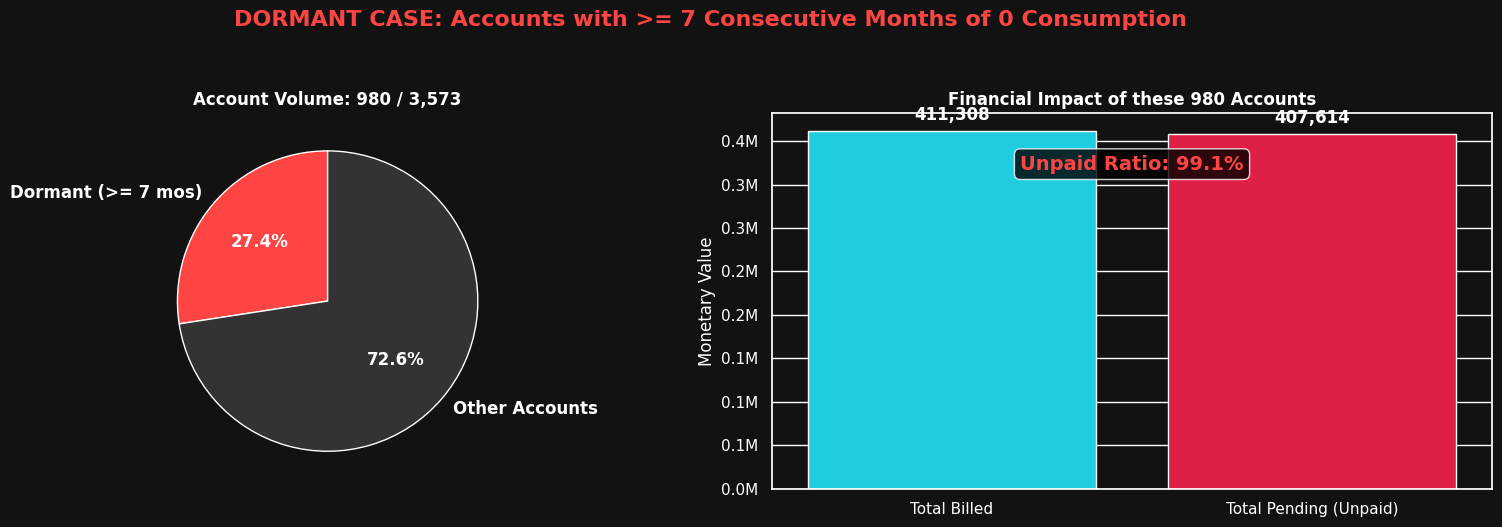

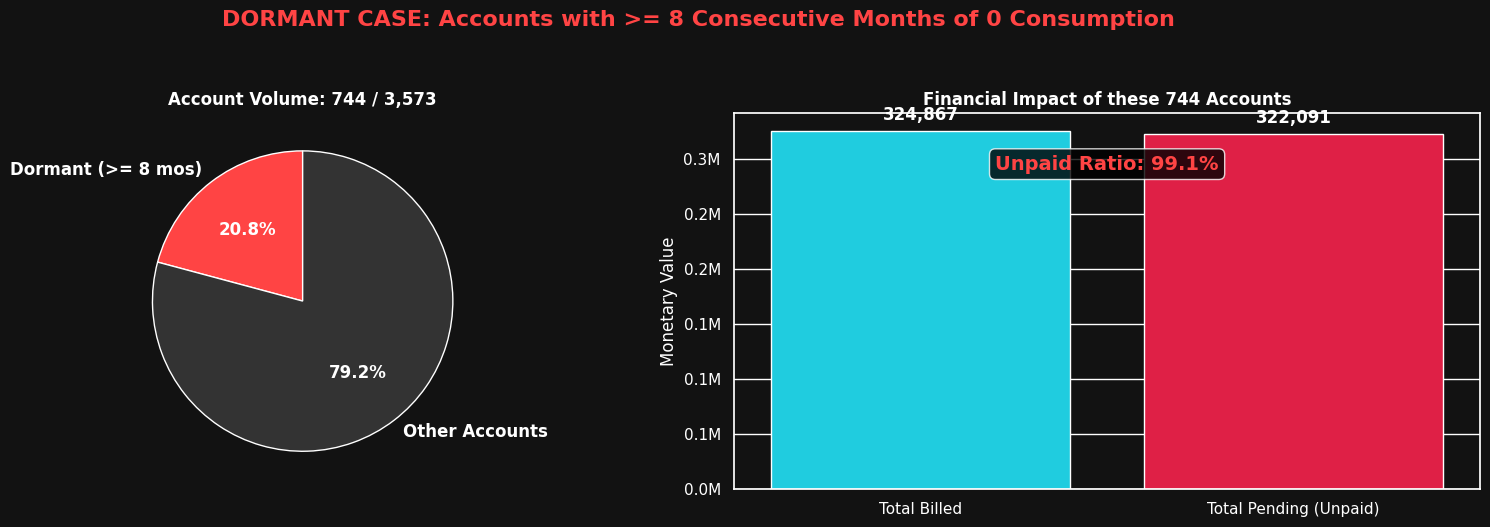

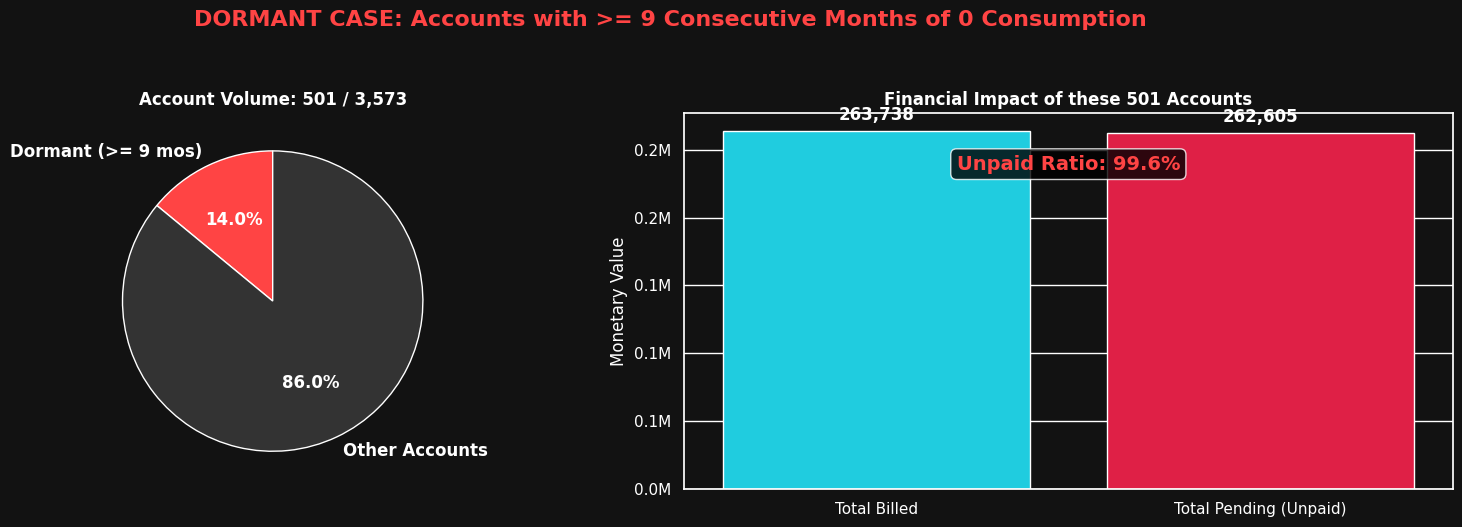

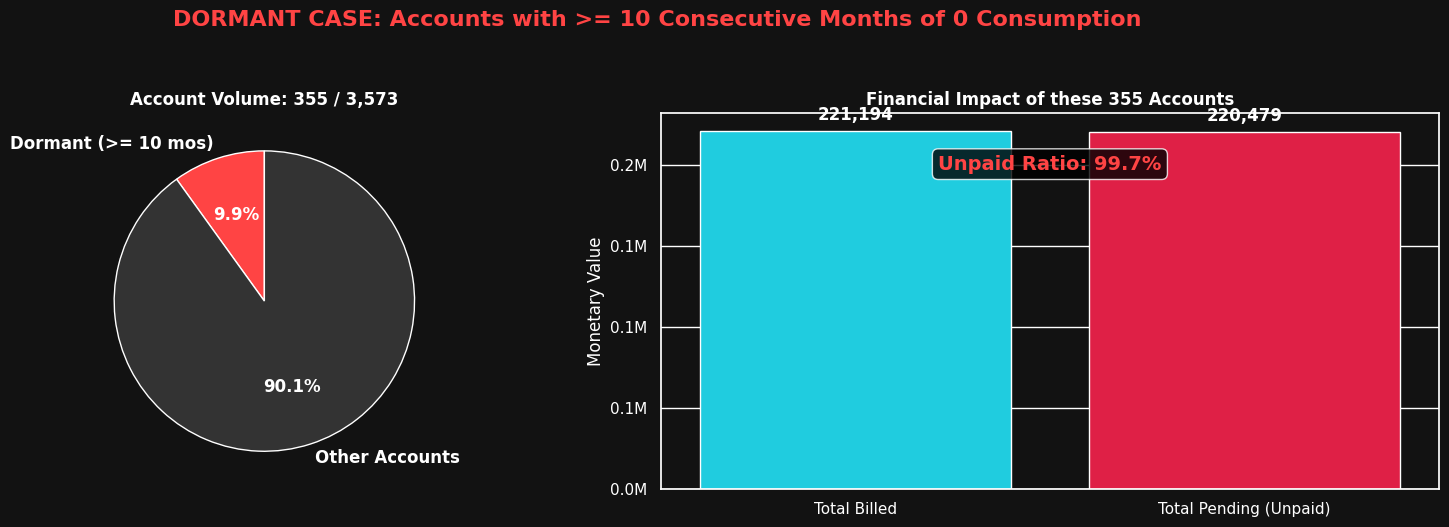

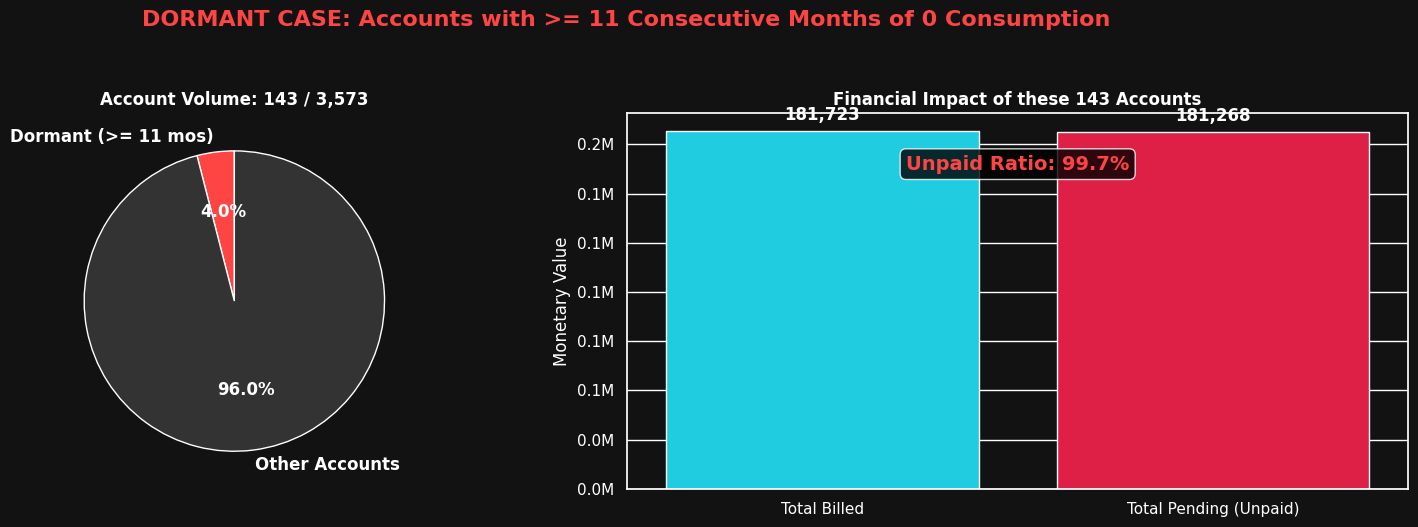

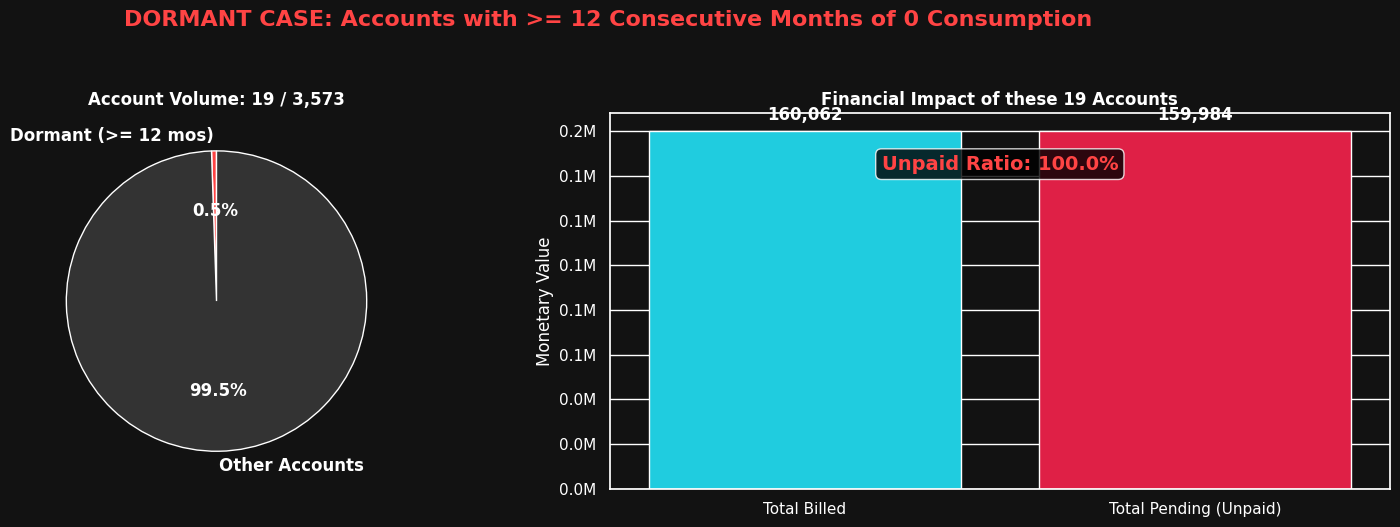

In [67]:
# 2. Define the requested dormancy thresholds
thresholds = [3, 5, 6, 7, 8, 9, 10, 11, 12]

# Get overall total metrics for percentage calculations
total_dataset_accounts = len(all_unique_accounts)
total_dataset_billed = telemetry_df['total_amount'].sum()
total_dataset_pending = telemetry_df['pending_amount'].sum()

# Set Seaborn theme temporarily
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# 3. Generate one plot per case
for n in thresholds:
    # Identify accounts dormant for >= N months
    dormant_accts = all_unique_accounts[all_unique_accounts['max_zero_streak'] >= n]['account#']
    num_dormant = len(dormant_accts)

    # Filter telemetry for these accounts to get their financial totals
    dormant_data = telemetry_df[telemetry_df['account#'].isin(dormant_accts)]
    dormant_billed = dormant_data['total_amount'].sum()
    dormant_pending = dormant_data['pending_amount'].sum()

    # Calculate percentages vs the whole dataset
    acct_pct = (num_dormant / total_dataset_accounts) * 100
    billed_pct = (dormant_billed / total_dataset_billed) * 100 if total_dataset_billed > 0 else 0
    unpaid_ratio = (dormant_pending / dormant_billed) * 100 if dormant_billed > 0 else 0

    # Create a 1x2 figure for this specific case
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'DORMANT CASE: Accounts with >= {n} Consecutive Months of 0 Consumption',
                 color='#FF4444', fontsize=16, fontweight='bold', y=1.05)

    # Plot 1: Account Proportion
    ax1 = axes[0]
    sizes = [num_dormant, total_dataset_accounts - num_dormant]
    labels = [f'Dormant (>= {n} mos)', 'Other Accounts']
    colors = ['#FF4444', '#333333']

    ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white', 'fontweight': 'bold', 'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
    ax1.set_title(f'Account Volume: {num_dormant:,} / {total_dataset_accounts:,}', color='white', fontweight='bold')

    # Plot 2: Financial Impact
    ax2 = axes[1]
    metrics = ['Total Billed', 'Total Pending (Unpaid)']
    values = [dormant_billed, dormant_pending]

    sns.barplot(x=metrics, y=values, palette=['#00E5FF', '#FF0033'], ax=ax2, hue=metrics, legend=False)
    ax2.set_title(f'Financial Impact of these {num_dormant:,} Accounts', color='white', fontweight='bold')
    ax2.set_ylabel('Monetary Value')
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))

    # Add value annotations
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, color='white', xytext=(0, 5),
                     textcoords='offset points', fontweight='bold')

    # Add a text box with the unpaid ratio
    props = dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='white')
    ax2.text(0.5, 0.85, f'Unpaid Ratio: {unpaid_ratio:.1f}%', transform=ax2.transAxes,
             fontsize=14, color='#FF4444', fontweight='bold', ha='center', bbox=props)

    plt.tight_layout()
    plt.show()

# Reset theme
sns.reset_orig()


## 37. Dormant Accounts: Time-Series Trends (Line Plots)
Now we will visualize the trend of the **Total Billed Amount** over time for each of the dormant account cohorts identified in the previous step.

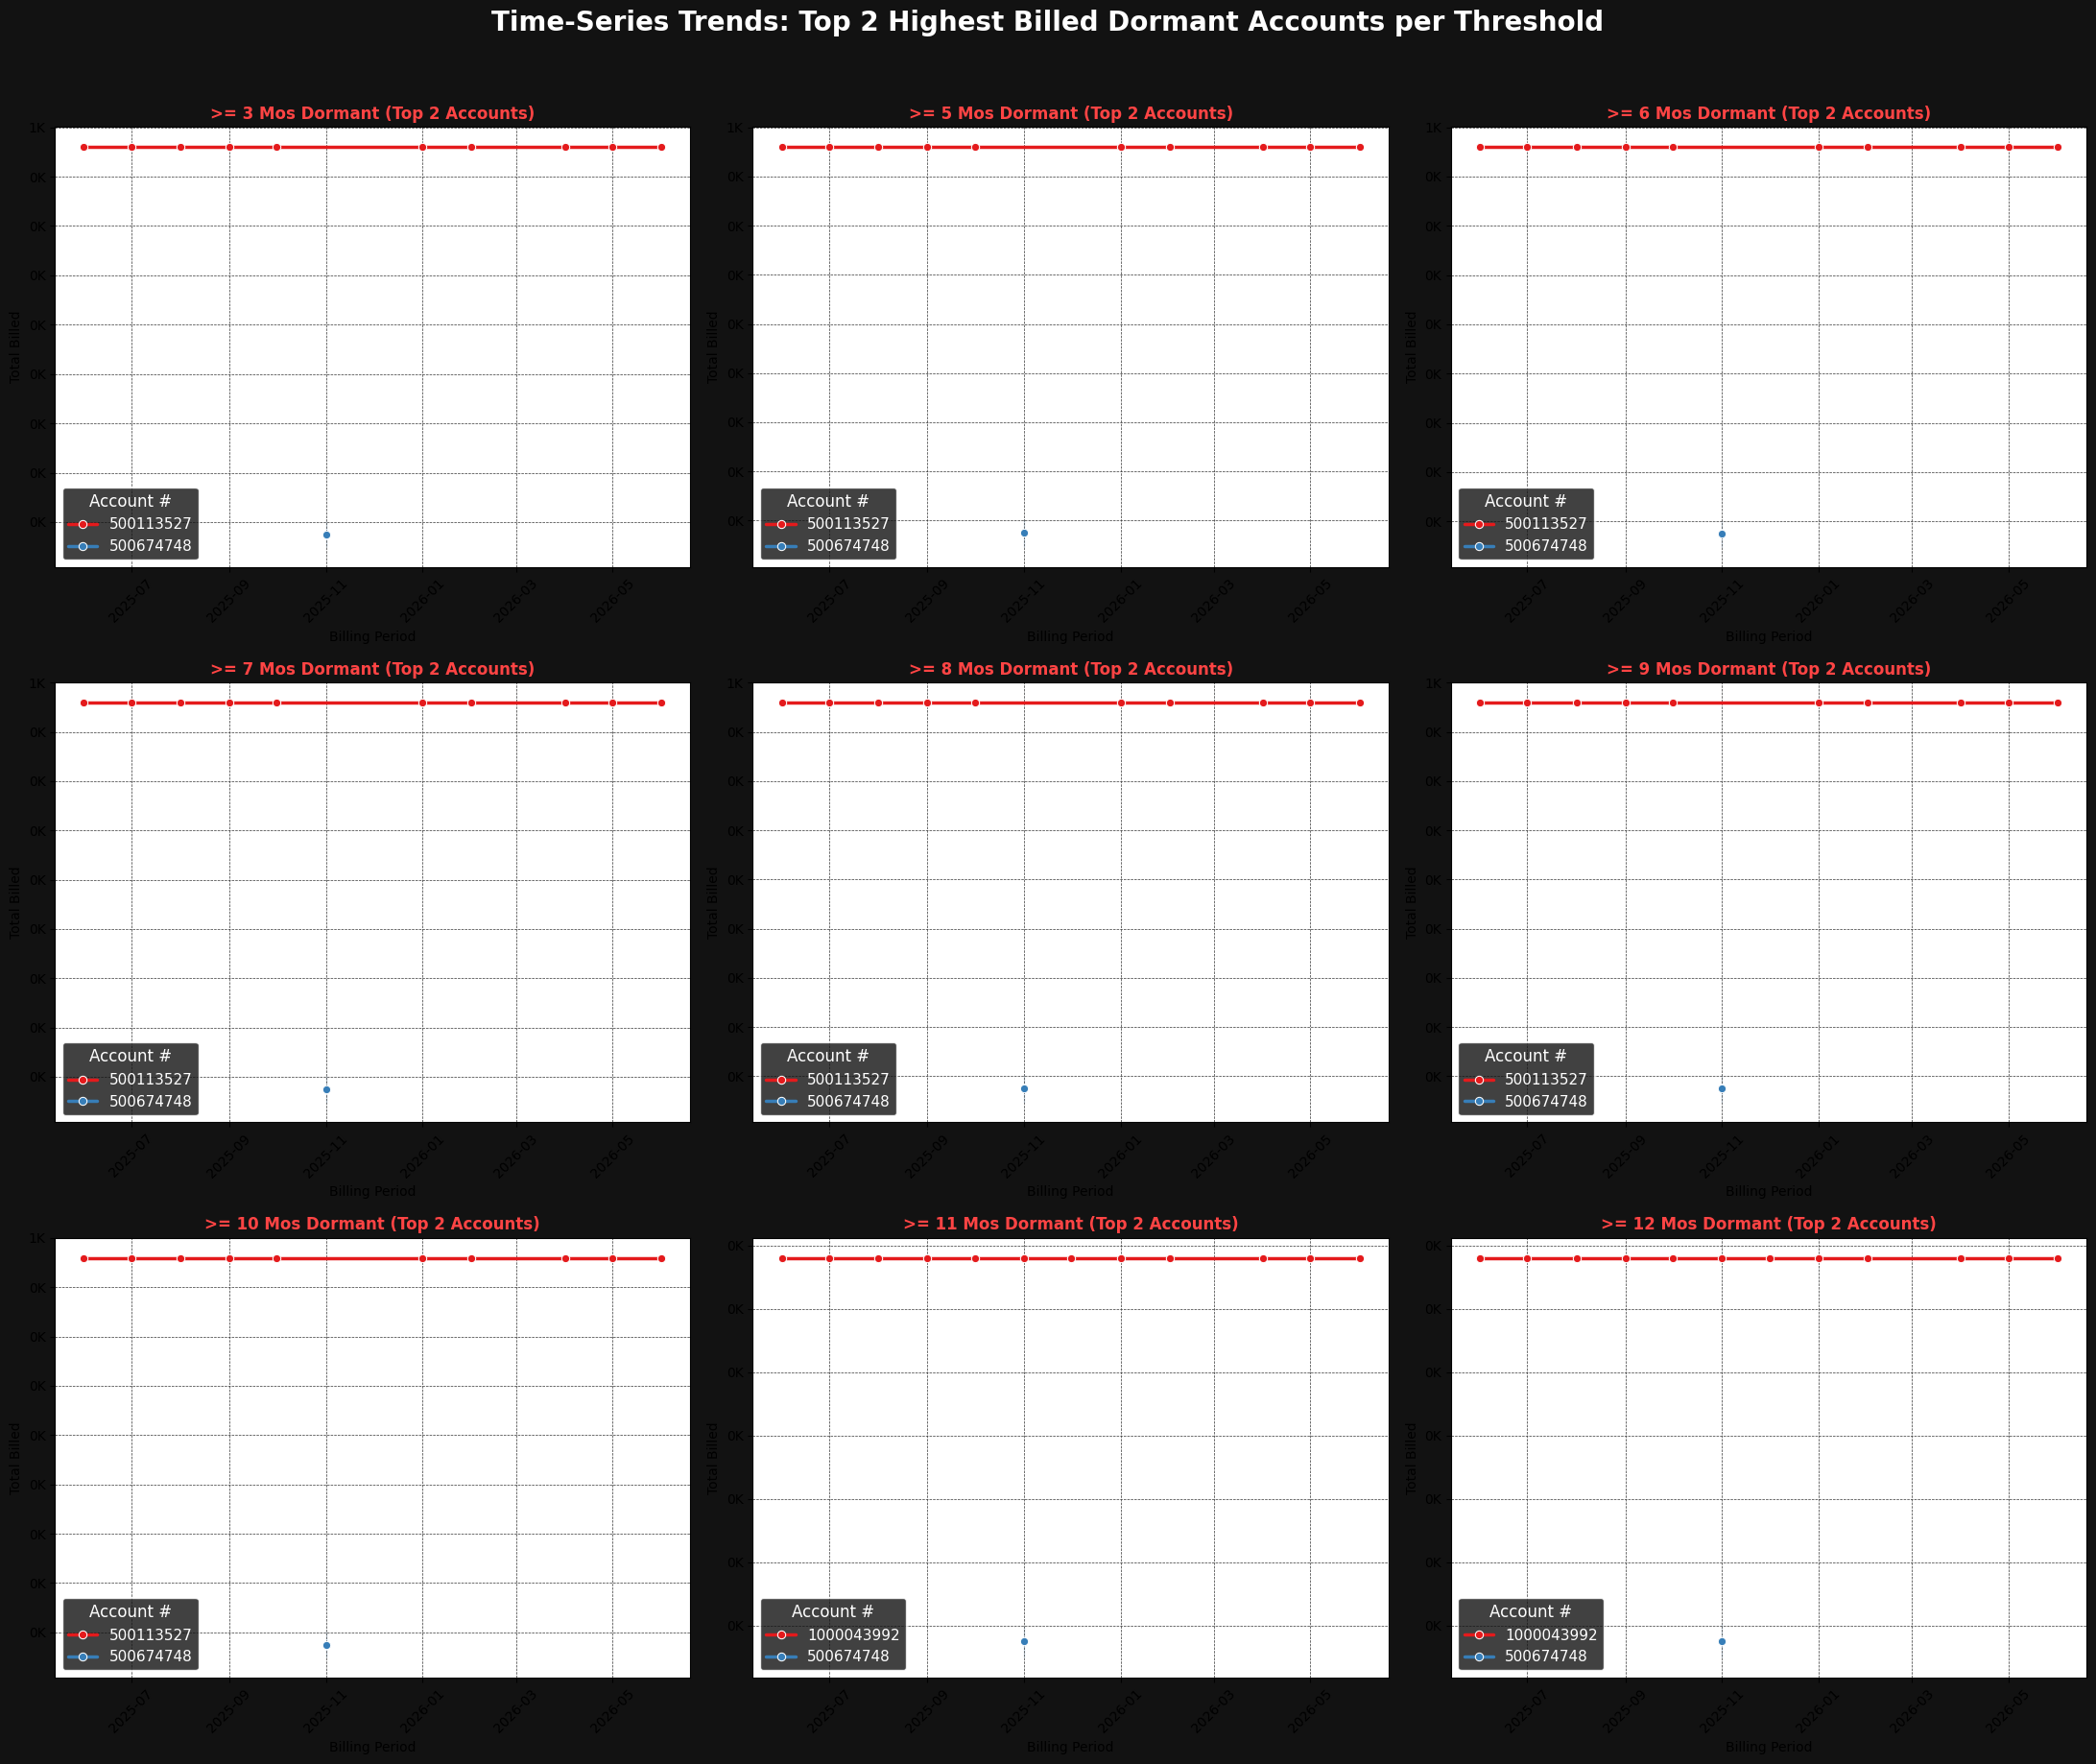

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd

# 1. Setup the 3x3 Grid
thresholds = [3, 5, 6, 7, 8, 9, 10, 11, 12]
fig, axes = plt.subplots(3, 3, figsize=(22, 18), facecolor='#121212')
fig.patch.set_facecolor('#121212')
axes = axes.flatten()

# Temporary dark theme
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# 2. Generate line plots for top 2 accounts in each cohort
for i, n in enumerate(thresholds):
    ax = axes[i]

    # Identify accounts dormant for >= N months
    dormant_accts = all_unique_accounts[all_unique_accounts['max_zero_streak'] >= n]['account#']

    if len(dormant_accts) == 0:
        ax.set_title(f'>= {n} Mos Dormant (No Accounts)', color='#FF4444')
        continue

    # Filter telemetry for these accounts
    dormant_data = telemetry_df[telemetry_df['account#'].isin(dormant_accts)]

    # Find the top 2 accounts by total billed amount in this cohort
    top_2_accts = dormant_data.groupby('account#')['total_amount'].sum().nlargest(2).index

    # Filter data for just these top 2 accounts
    top_2_data = dormant_data[dormant_data['account#'].isin(top_2_accts)].copy()

    # Ensure dates are properly sorted
    top_2_data = top_2_data.sort_values(['account#', 'billing_period'])

    # Plot the lines
    sns.lineplot(data=top_2_data, x='billing_period', y='total_amount', hue='account#',
                 palette='Set1', ax=ax, linewidth=2.5, marker='o', markersize=6)

    # Styling
    ax.set_title(f'>= {n} Mos Dormant (Top 2 Accounts)', color='#FF4444', fontweight='bold', fontsize=12)
    ax.set_xlabel('Billing Period')
    ax.set_ylabel('Total Billed')

    # Format Y-axis to K (Thousands)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e3:,.0f}K'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(color='#333333', linestyle='--', linewidth=0.5)

    # Fix legend styling
    if ax.get_legend() is not None:
        legend = ax.legend(facecolor='#121212', edgecolor='white', title='Account #')
        plt.setp(legend.get_texts(), color='white')
        plt.setp(legend.get_title(), color='white')

plt.suptitle('Time-Series Trends: Top 2 Highest Billed Dormant Accounts per Threshold', color='white', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()


## 38. Payment Behavior: Top Dormant Accounts
Let's analyze the payment behavior for the **Top 5 highest-billed accounts** within each dormancy threshold. We will look at their aggregate Paid versus Unpaid (Pending) amounts to see if these high-value dormant accounts are actually paying their bills.

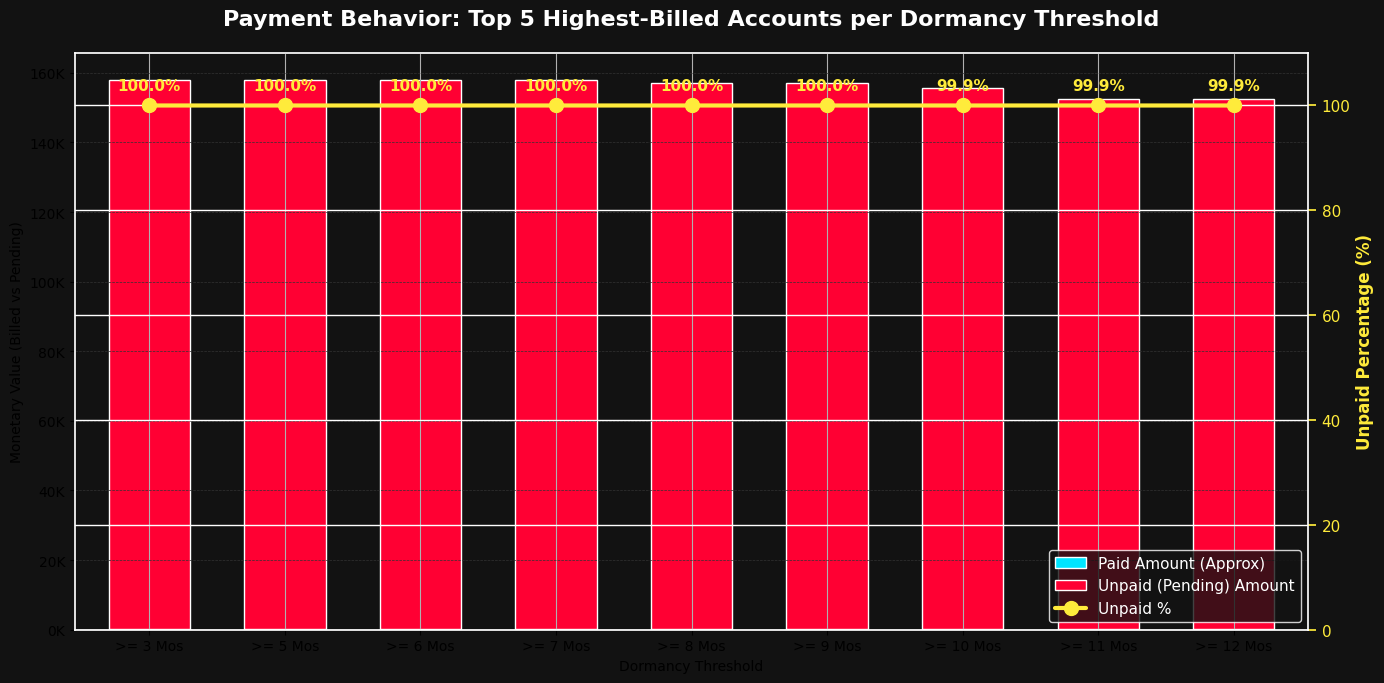

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Prepare Payment Data for Top 5 Accounts per Threshold
thresholds = [3, 5, 6, 7, 8, 9, 10, 11, 12]
payment_data = []

for n in thresholds:
    dormant_accts = all_unique_accounts[all_unique_accounts['max_zero_streak'] >= n]['account#']
    if len(dormant_accts) == 0:
        continue

    # Filter telemetry for these accounts
    dormant_data = telemetry_df[telemetry_df['account#'].isin(dormant_accts)]

    # Identify the Top 5 accounts by total billed amount in this threshold
    top_5_accts = dormant_data.groupby('account#')['total_amount'].sum().nlargest(5).index
    top_5_data = dormant_data[dormant_data['account#'].isin(top_5_accts)]

    # Calculate financials
    total_billed = top_5_data['total_amount'].sum()
    total_pending = top_5_data['pending_amount'].sum()
    total_paid = total_billed - total_pending

    payment_data.append({
        'Threshold': f'>= {n} Mos',
        'Total_Billed': total_billed,
        'Total_Pending': total_pending,
        'Total_Paid': total_paid if total_paid > 0 else 0, # Prevent negatives from data anomalies
        'Unpaid_Pct': (total_pending / total_billed * 100) if total_billed > 0 else 0
    })

payment_df = pd.DataFrame(payment_data)

# 2. Visualizing the Payment Behavior
fig, ax1 = plt.subplots(figsize=(14, 7), facecolor='#121212')
ax1.set_facecolor('#121212')

# Temporary dark theme
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# Plot Stacked Bar Chart: Paid vs Pending (Unpaid)
payment_df.set_index('Threshold')[['Total_Paid', 'Total_Pending']].plot(
    kind='bar', stacked=True, color=['#00E5FF', '#FF0033'], ax=ax1, edgecolor='white', width=0.6
)

# Styling for Bar Chart
ax1.set_title('Payment Behavior: Top 5 Highest-Billed Accounts per Dormancy Threshold', color='white', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Monetary Value (Billed vs Pending)')
ax1.set_xlabel('Dormancy Threshold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e3:,.0f}K'))
ax1.tick_params(axis='x', rotation=0)
ax1.grid(color='#333333', linestyle='--', linewidth=0.5, axis='y')

# Add Secondary Axis for Unpaid Percentage Line
ax2 = ax1.twinx()
ax2.plot(range(len(payment_df)), payment_df['Unpaid_Pct'], color='#FFEB3B', marker='o', linewidth=3, markersize=10, label='Unpaid %')
ax2.set_ylabel('Unpaid Percentage (%)', color='#FFEB3B', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', colors='#FFEB3B')
ax2.set_ylim(0, 110)

# Annotate percentages on the line
for i, v in enumerate(payment_df['Unpaid_Pct']):
    ax2.text(i, v + 3, f'{v:.1f}%', color='#FFEB3B', ha='center', fontweight='bold', fontsize=11)

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, ['Paid Amount (Approx)', 'Unpaid (Pending) Amount', 'Unpaid %'],
           facecolor='#121212', edgecolor='white', loc='lower right')

plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()


## 39. Intermittent Dormancy (Gap) Analysis
We will now identify accounts that exhibit "gaps" in their billed consumption. We define a gap as a period where an account transitions from active (`>0` consumption) to dormant (`0` consumption) and back again. We will explicitly exclude the anomalous **March 2026** period to prevent false gap detection.

========== INTERMITTENT DORMANCY SUMMARY ==========
Total accounts evaluated: 3,573
Accounts with intermittent consumption gaps (>= 2 state changes): 1,347


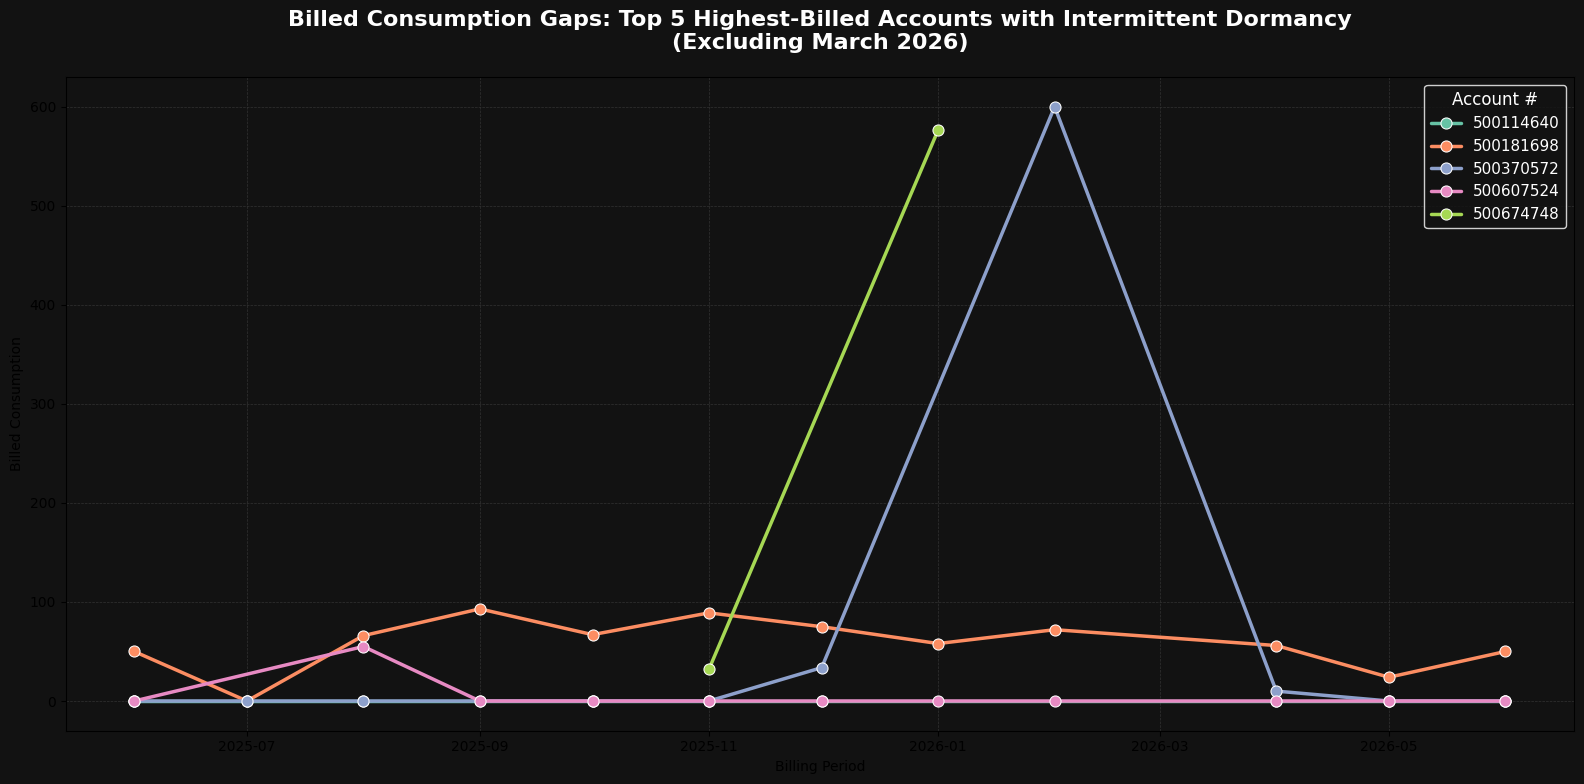

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Filter out the March 2026 anomaly
missing_month = pd.to_datetime('2026-03-01')
working_df = telemetry_df[telemetry_df['billing_period'] != missing_month].copy()

# 2. Sort chronologically by Account to track state changes over time
working_df = working_df.sort_values(['account#', 'billing_period'])

# 3. Define the consumption state: True if exactly 0, False if >0
working_df['is_zero'] = (working_df['billed_consumption'] == 0)

# 4. Calculate state transitions
# Shift the state down by 1 within each account to get the previous month's state
working_df['prev_state'] = working_df.groupby('account#')['is_zero'].shift(1)

# A state change occurs when the current state does not match the previous state
# (and the previous state isn't NaN, which happens on the first row of each account)
working_df['state_change'] = (working_df['is_zero'] != working_df['prev_state']) & (working_df['prev_state'].notna())

# 5. Identify "Gap" Accounts
# A true gap requires at least 2 state changes (e.g., Active -> Dormant -> Active)
state_changes_per_acct = working_df.groupby('account#')['state_change'].sum()
gap_accounts = state_changes_per_acct[state_changes_per_acct >= 2].index

print("========== INTERMITTENT DORMANCY SUMMARY ==========")
print(f"Total accounts evaluated: {working_df['account#'].nunique():,}")
print(f"Accounts with intermittent consumption gaps (>= 2 state changes): {len(gap_accounts):,}")

# 6. Prepare Data for Visualization
# Filter to only the gap accounts
gap_df = working_df[working_df['account#'].isin(gap_accounts)]

# Find the Top 5 gap accounts by total billed amount to visualize the most financially impactful ones
top_5_gap_accts = gap_df.groupby('account#')['total_amount'].sum().nlargest(5).index
sample_gap_df = gap_df[gap_df['account#'].isin(top_5_gap_accts)]

# 7. Visualization
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#121212')
ax.set_facecolor('#121212')

# Temporary dark theme
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# Plot the consumption lines
sns.lineplot(data=sample_gap_df, x='billing_period', y='billed_consumption', hue='account#',
             palette='Set2', marker='o', linewidth=2.5, markersize=8, ax=ax)

# Styling
ax.set_title('Billed Consumption Gaps: Top 5 Highest-Billed Accounts with Intermittent Dormancy\n(Excluding March 2026)', color='white', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Billed Consumption')
ax.set_xlabel('Billing Period')
ax.grid(color='#333333', linestyle='--', linewidth=0.5)

# Fix legend styling
if ax.get_legend() is not None:
    legend = ax.legend(facecolor='#121212', edgecolor='white', title='Account #')
    plt.setp(legend.get_texts(), color='white')
    plt.setp(legend.get_title(), color='white')

plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()


## 40. Intermittent Dormancy (Individual Account Views)
Here we separate the top 5 highest-billed accounts with consumption gaps into their own individual plots for clearer visibility of their specific activity patterns.

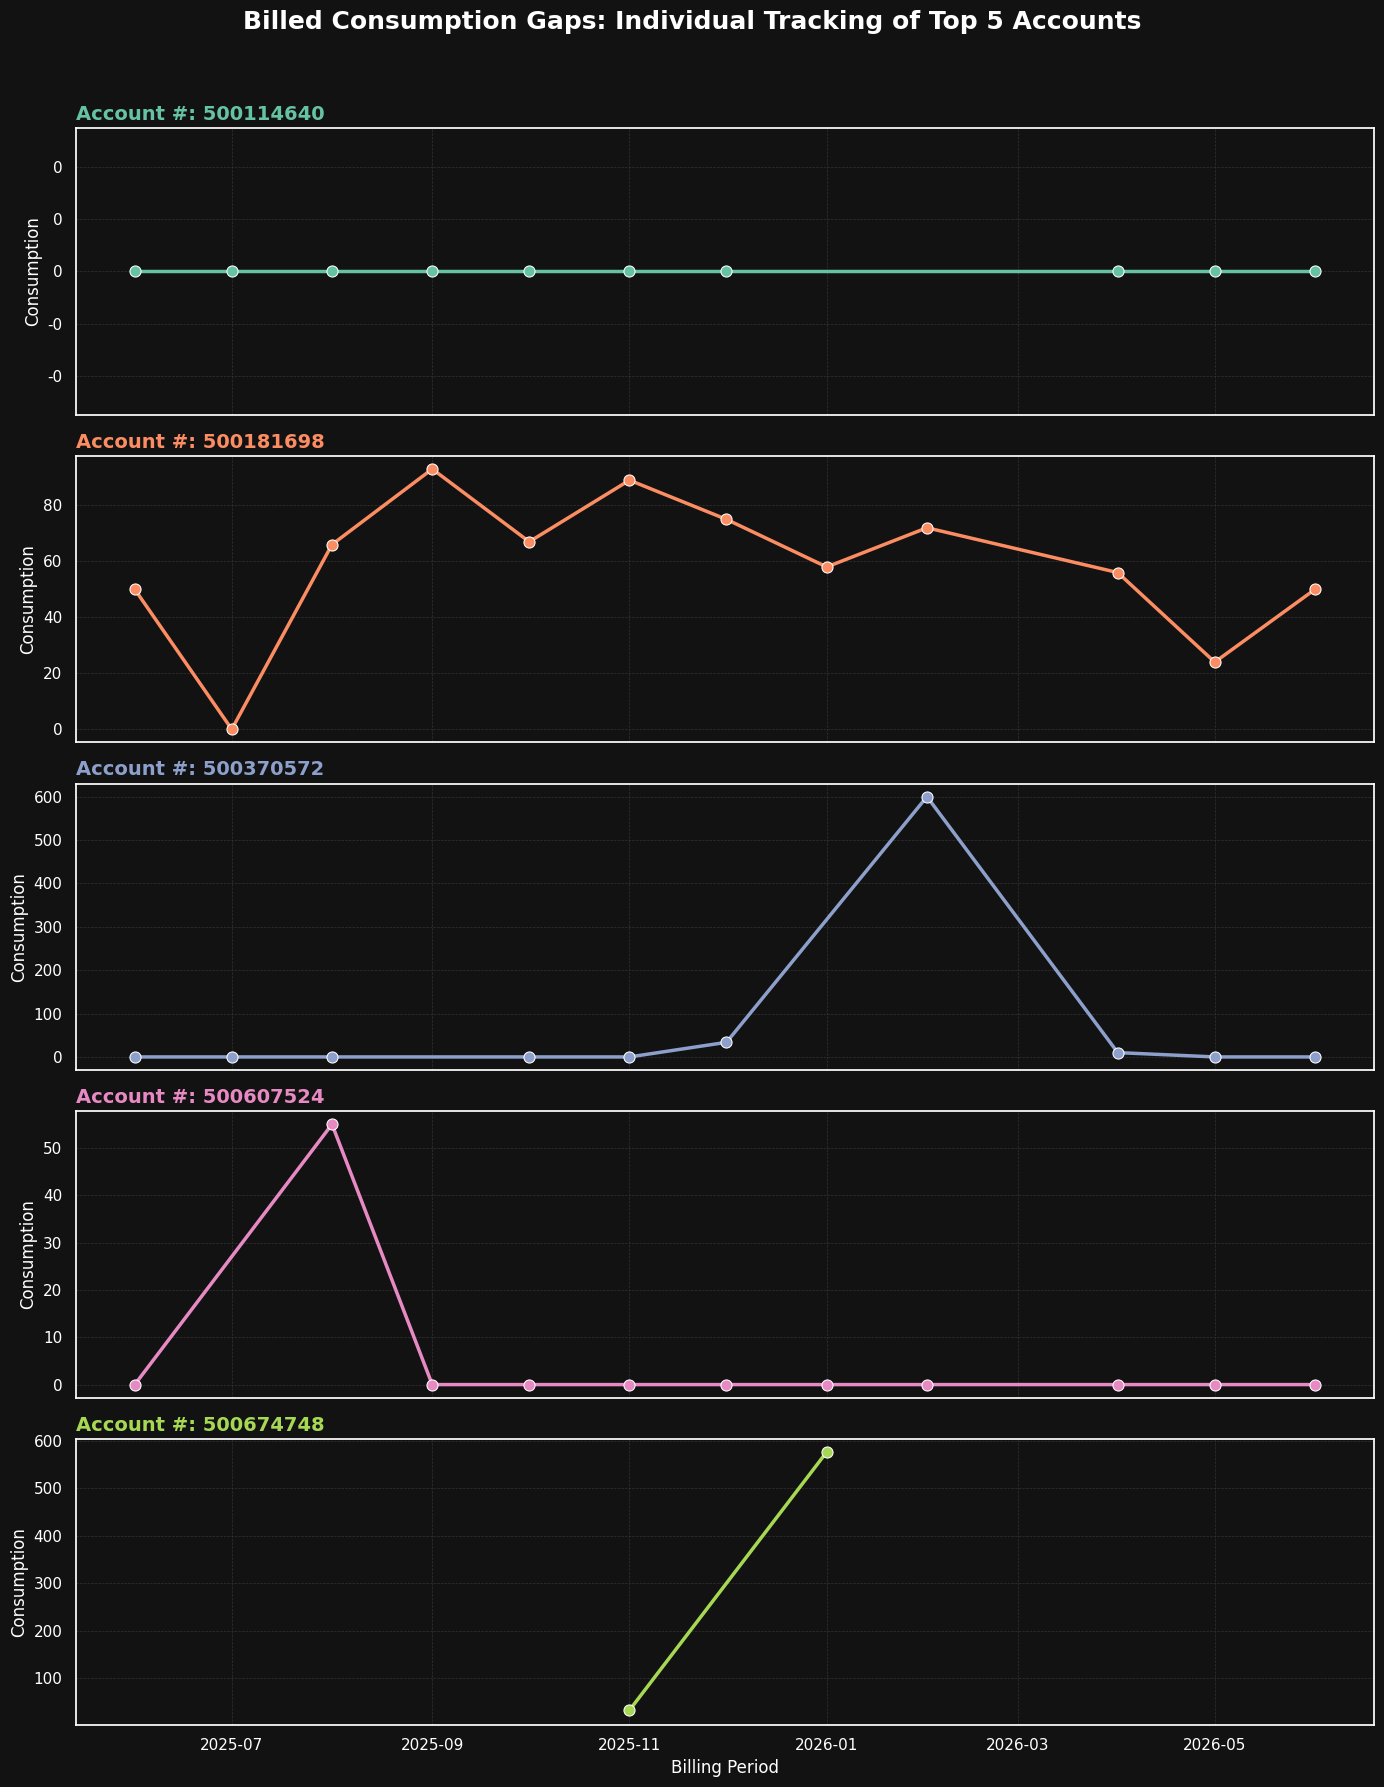

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Temporary dark theme
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# Get the unique accounts from our top 5 sample
unique_gap_accts = sample_gap_df['account#'].unique()

# Create a figure with vertically stacked subplots
fig, axes = plt.subplots(nrows=len(unique_gap_accts), ncols=1, figsize=(14, 3.5 * len(unique_gap_accts)), sharex=True, facecolor='#121212')

# Color palette to differentiate them slightly
colors = sns.color_palette("Set2", len(unique_gap_accts))

for i, acct in enumerate(unique_gap_accts):
    ax = axes[i]
    acct_data = sample_gap_df[sample_gap_df['account#'] == acct]

    # Plot individual line
    sns.lineplot(data=acct_data, x='billing_period', y='billed_consumption',
                 marker='o', linewidth=2.5, markersize=8, color=colors[i], ax=ax)

    # Styling for each subplot
    ax.set_title(f'Account #: {acct}', color=colors[i], fontweight='bold', fontsize=14, loc='left')
    ax.set_ylabel('Consumption', color='white')
    ax.grid(color='#333333', linestyle='--', linewidth=0.5)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# Set X-axis label only on the bottom plot
axes[-1].set_xlabel('Billing Period', color='white', fontsize=12)

plt.suptitle('Billed Consumption Gaps: Individual Tracking of Top 5 Accounts', color='white', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()


## 41. Correlation: Account Type (Tariff) vs. Dormancy
We will now investigate if certain account types (defined by their `tariff`, such as Commercial, Domestic, etc.) are more prone to experiencing dormancy. We will look at the percentage of accounts within each tariff that go dormant, as well as the severity of their dormancy (average maximum streak).

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Get the primary account type (tariff) for each account
# Since an account might rarely change tariffs, we take the most frequent one (mode)
tariff_map = combined_df.dropna(subset=['tariff']).groupby('account#')['tariff'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown').reset_index()

# 2. Merge with our previously calculated max streak data
dormancy_corr_df = all_unique_accounts.merge(tariff_map, on='account#', how='left')

# Fill any missing tariffs with 'Unknown'
dormancy_corr_df['tariff'] = dormancy_corr_df['tariff'].fillna('Unknown')

# Group smaller tariff categories into 'Other' for cleaner visualization
top_tariffs = dormancy_corr_df['tariff'].value_counts().nlargest(4).index
dormancy_corr_df['tariff_group'] = dormancy_corr_df['tariff'].apply(lambda x: x if x in top_tariffs else 'Other')

# 3. Calculate Dormancy Statistics per Tariff Group
tariff_stats = dormancy_corr_df.groupby('tariff_group').agg(
    total_accounts=('account#', 'count'),
    any_dormancy=('max_zero_streak', lambda x: (x > 0).sum()),
    high_dormancy=('max_zero_streak', lambda x: (x >= 6).sum()), # 6+ months dormant
    avg_streak=('max_zero_streak', 'mean')
).reset_index()

# Calculate percentages
tariff_stats['dormancy_rate'] = (tariff_stats['any_dormancy'] / tariff_stats['total_accounts']) * 100
tariff_stats['high_dormancy_rate'] = (tariff_stats['high_dormancy'] / tariff_stats['total_accounts']) * 100

# Sort by total accounts to keep the biggest groups first
tariff_stats = tariff_stats.sort_values('total_accounts', ascending=False)

print("========== ACCOUNT TYPE (TARIFF) DORMANCY STATS ==========")
display(tariff_stats)

========== ACCOUNT TYPE (TARIFF) DORMANCY STATS ==========


,tariff_group,total_accounts,any_dormancy,high_dormancy,avg_streak,dormancy_rate,high_dormancy_rate
1,T1-Residential - Postpayment,2607,2353,1014,4.672037,90.257000,38.895282
4,T4-MDI – Postpayment-Monthly,779,169,19,0.677792,21.694480,2.439024
2,T2-Commercial – Postpayment,86,67,37,4.546512,77.906977,43.023256
0,Other,59,6,0,0.372881,10.169492,0.000000
3,T3-Institutions – Postpayment,42,34,22,5.833333,80.952381,52.380952


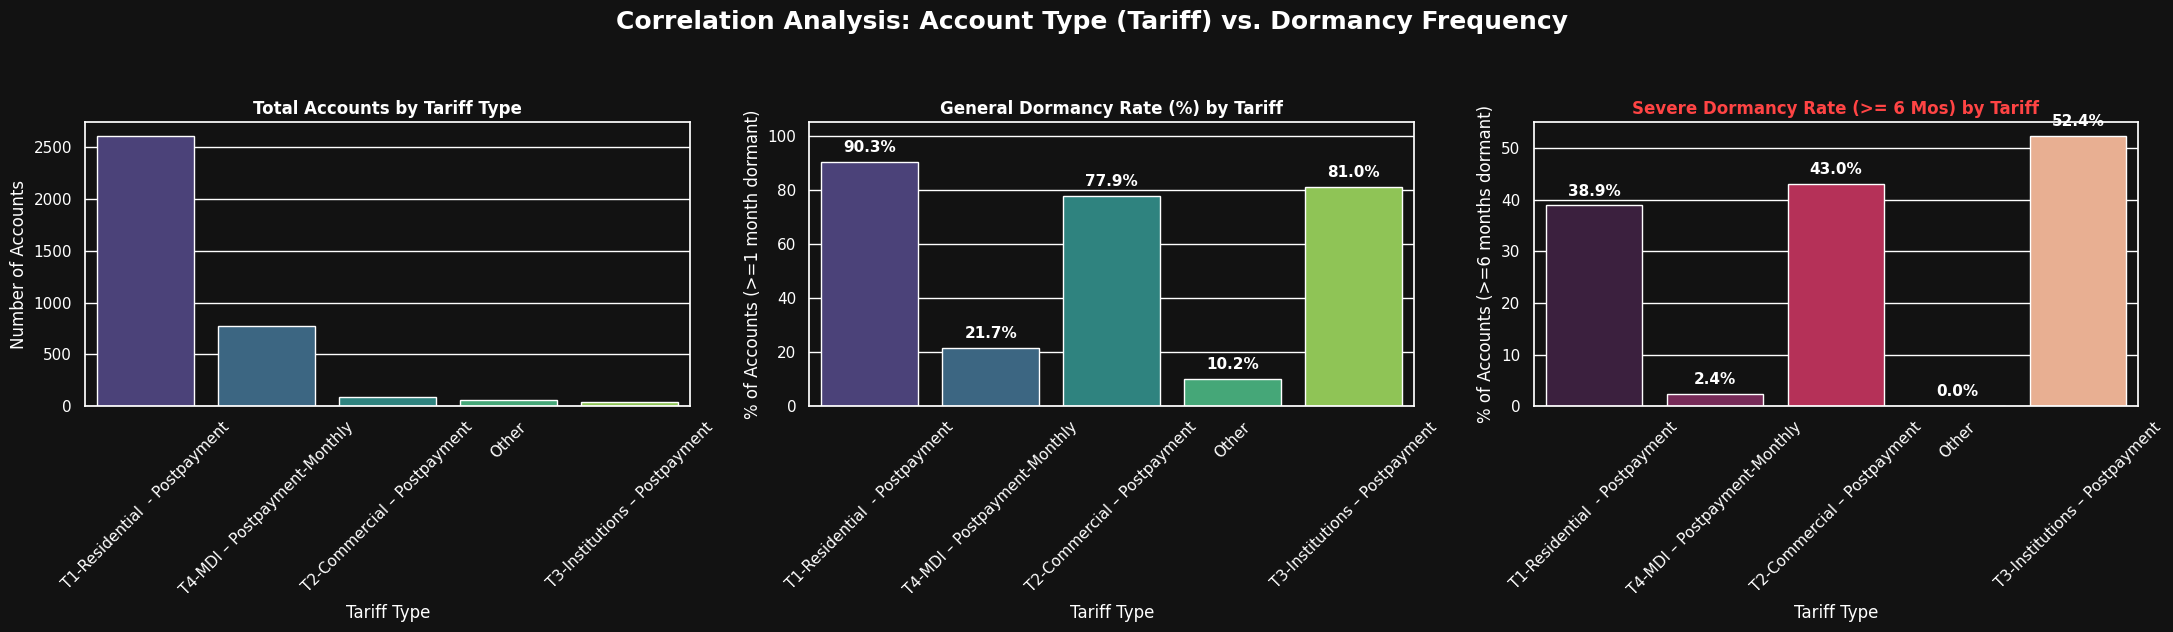

In [74]:
import matplotlib.ticker as ticker

# 4. Visualizing the Correlation
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('#121212')
colors = sns.color_palette("viridis", len(tariff_stats))

# Plot 1: Total Accounts per Tariff (Context)
sns.barplot(data=tariff_stats, x='tariff_group', y='total_accounts', palette=colors, ax=axes[0], hue='tariff_group', legend=False)
axes[0].set_title('Total Accounts by Tariff Type', fontweight='bold', color='white')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_xlabel('Tariff Type')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Dormancy Rate (% of accounts with >= 1 month of 0 consumption)
sns.barplot(data=tariff_stats, x='tariff_group', y='dormancy_rate', palette=colors, ax=axes[1], hue='tariff_group', legend=False)
axes[1].set_title('General Dormancy Rate (%) by Tariff', fontweight='bold', color='white')
axes[1].set_ylabel('% of Accounts (>=1 month dormant)')
axes[1].set_xlabel('Tariff Type')
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=45)

# Add percentage labels
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='white', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Plot 3: Severe Dormancy Rate (% of accounts with >= 6 consecutive months of 0 consumption)
sns.barplot(data=tariff_stats, x='tariff_group', y='high_dormancy_rate', palette='rocket', ax=axes[2], hue='tariff_group', legend=False)
axes[2].set_title('Severe Dormancy Rate (>= 6 Mos) by Tariff', fontweight='bold', color='#FF4444')
axes[2].set_ylabel('% of Accounts (>=6 months dormant)')
axes[2].set_xlabel('Tariff Type')
axes[2].tick_params(axis='x', rotation=45)

# Add percentage labels
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='white', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle('Correlation Analysis: Account Type (Tariff) vs. Dormancy Frequency', color='white', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()

## 42. Anomalies in Western Region
Let's analyze the distribution of anomalies specifically within the Western region.

========== ANOMALIES IN WESTERN REGION ==========
Total records in Western Region: 32,118


,count
anomalies,
N,20894
Y,11224


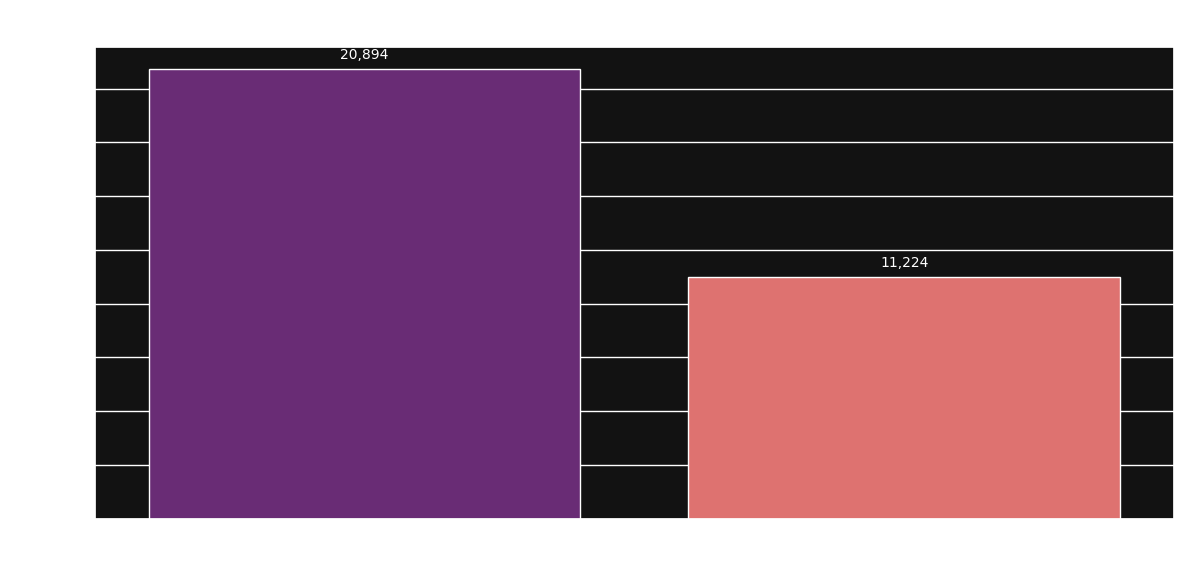

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure combined_df is loaded in case of kernel restart
if 'combined_df' not in globals():
    combined_df = pd.read_csv('/content/drive/MyDrive/2026/other/ed sa/postpaid data/silver_postpaid_data.csv')

# 1. Filter for the Western region
western_df = combined_df[combined_df['region'].astype(str).str.strip().str.upper() == 'WESTERN'].copy()

# 2. Clean the anomalies column (handle NaNs and standardize)
western_df['anomalies'] = western_df['anomalies'].fillna('None')
western_df['anomalies'] = western_df['anomalies'].astype(str).str.strip()

# Calculate counts
anomaly_counts = western_df['anomalies'].value_counts()

print("========== ANOMALIES IN WESTERN REGION ==========")
print(f"Total records in Western Region: {len(western_df):,}")
display(anomaly_counts)

# 3. Visualization
# Exclude 'None' if it dominates too much, but let's show it first for context.
plt.figure(figsize=(12, 6))
# Use a dark theme for consistency
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

ax = sns.barplot(x=anomaly_counts.index, y=anomaly_counts.values, hue=anomaly_counts.index, palette='magma', legend=False)

plt.title('Distribution of Anomalies in Western Region', color='white', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Anomaly Type', color='white')
plt.ylabel('Number of Occurrences', color='white')
plt.xticks(rotation=45, ha='right')

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='white', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()


## 43. Anomalies Breakdown by District (Western Region)
Since the data only indicates the presence of an anomaly ('Y' or 'N'), let's break down where these anomalies are concentrated geographically within the region.

========== ANOMALIES BY DISTRICT (WESTERN REGION) ==========


,District,Anomaly Count
0,82-FREETOWN EAST RURAL,6332
1,83-FREETOWN EAST,2478
2,80-FREETOWN WEST,481
3,84-FREETOWN WEST RURAL,442
4,75-FREETOWN CENTRAL,294
5,72-FREETOWN CENTRAL,229
6,81-FREETOWN WEST,203
7,70-FREETOWN CENTRAL,151
8,79-FREETOWN CENTRAL,120
9,77-FREETOWN CENTRAL,111


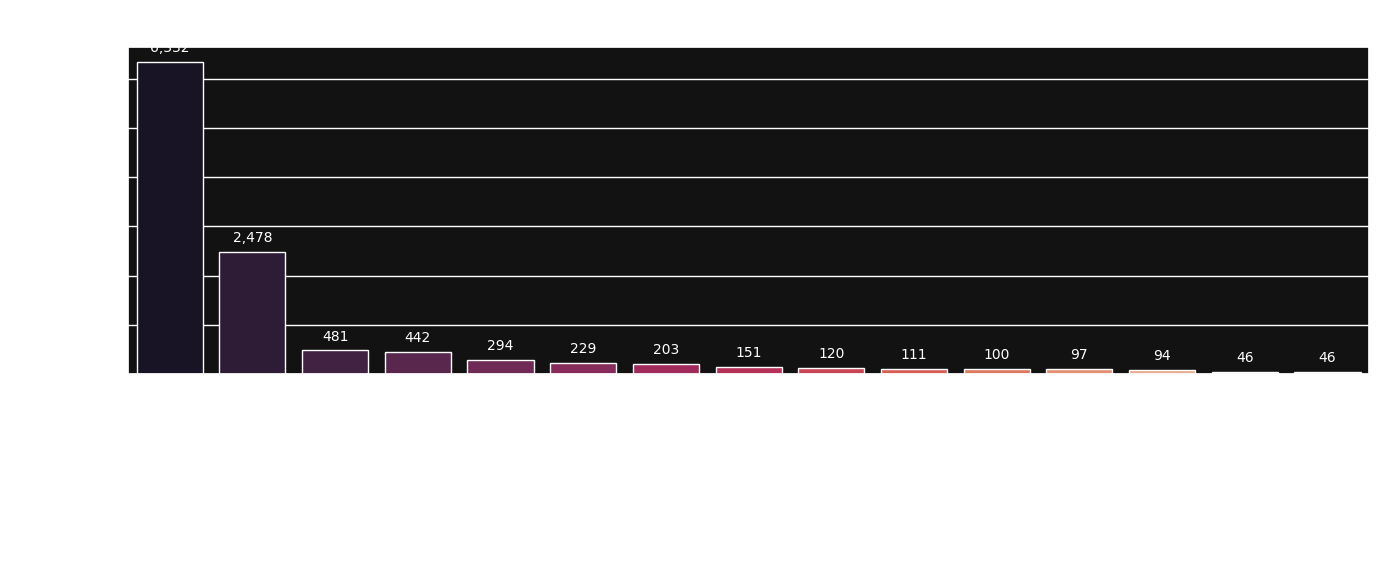

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for only the records WITH anomalies ('Y') in the Western region
western_anomalies_df = western_df[western_df['anomalies'] == 'Y'].copy()

# 2. Count anomalies by district
district_anomalies = western_anomalies_df['district'].value_counts().reset_index()
district_anomalies.columns = ['District', 'Anomaly Count']

print("========== ANOMALIES BY DISTRICT (WESTERN REGION) ==========")
display(district_anomalies)

# 3. Visualization
plt.figure(figsize=(14, 6))
# Use a dark theme for consistency
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

ax = sns.barplot(data=district_anomalies, x='District', y='Anomaly Count', hue='District', palette='rocket', legend=False)

plt.title('Concentration of Anomalies by District in the Western Region', color='white', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('District', color='white')
plt.ylabel('Number of Anomalies', color='white')
plt.xticks(rotation=45, ha='right')

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='white', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Reset theme
sns.reset_orig()
